# GRU layers

# Data prep + Training

In [1]:

def plot_loss_curves(history):

  loss = history.history['loss']
  val_loss = history.history['val_loss']

  accuracy = history.history['accuracy']
  val_accuracy = history.history['val_accuracy']

  epochs = range(0,20)

  # Plot loss
  plt.plot(epochs, loss, label='training_loss')
  plt.plot(epochs, val_loss, label='val_loss')
  plt.title('Loss')
  plt.xlabel('Epochs')
  plt.legend()

  # Plot accuracy
  plt.figure()
  plt.plot(epochs, accuracy, label='training_accuracy')
  plt.plot(epochs, val_accuracy, label='val_accuracy')
  plt.title('Accuracy')
  plt.xlabel('Epochs')
  plt.legend()


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mne


In [3]:
import os

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
eeg_path=[]
meta_path=[]
for root, dir , files in os.walk('.'):

   for file in files:
    if file.endswith(('.csv', '.zip')):

      if 'nig' in file.lower() :
         eeg_path.append (os.path.join(root,file))
      if 'meta' in file.lower():
         meta_path.append ( os.path.join(root,file))





In [5]:
eeg_path

['.\\EEGs_Nigeria.zip', '.\\metadata_nigeria.csv']

In [6]:
meta_path

['.\\metadata_nigeria.csv']

In [7]:
eeg_path

['.\\EEGs_Nigeria.zip', '.\\metadata_nigeria.csv']

In [8]:
import zipfile
with zipfile.ZipFile(eeg_path[0], 'r') as eeg:
    eeg.extractall('data')

In [9]:
def convertDF2MNE(sub):
    info = mne.create_info(list(sub.columns), ch_types=['eeg'] * len(sub.columns), sfreq=128)
    info.set_montage('standard_1020')
    data=mne.io.RawArray(sub.T, info)
    data.set_eeg_reference()
    data.filter(l_freq=1,h_freq=30)
    epochs=mne.make_fixed_length_epochs(data,duration=5,overlap=1)
    epochs=epochs.drop_bad()
    return epochs.get_data()

In [10]:
meta_df = pd.read_csv(meta_path[0])

In [11]:
EP_sub = meta_df['subject.id'][meta_df['Group']=='epilepsy']
CT_sub = meta_df['subject.id'][meta_df['Group']=='control']
def appender(items,limit):
  iter = 0
  item = []
  for i in items:
    if (iter==limit):
      break
    try:
      reader = pd.read_csv('data/EEGs_Nigeria/signal-{}-1.csv.gz'.format(i), compression='gzip')
      item.append(reader)
      iter=iter+1
    except:
      try:
        reader = pd.read_csv('data/EEGs_Nigeria/signal-{}-2.csv.gz'.format(i), compression='gzip')
        item.append(reader)
        iter=iter+1
      except:
        pass
  return item
Epilepsy = appender(EP_sub,51)
Control = appender(CT_sub,46)
Epilepsy2 = [i.iloc[:,1:15] for i in  Epilepsy]
Control2 = [i.iloc[:,1:15] for i in  Control]
idd_subject =[convertDF2MNE(i) for i in  Epilepsy2]
tdc_subject = [convertDF2MNE(i) for i in  Control2]

Creating RawArray with float64 data, n_channels=14, n_times=34304
    Range : 0 ... 34303 =      0.000 ...   267.992 secs
Ready.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


ValueError: assignment destination is read-only

In [12]:
import numpy as np
import mne

def convertDF2MNE(sub):
    info = mne.create_info(
        ch_names=list(sub.columns),
        ch_types=['eeg'] * len(sub.columns),
        sfreq=128
    )

    info.set_montage('standard_1020')

    # Make a writable NumPy array
    eeg_data = sub.to_numpy(dtype=np.float64).T.copy()

    print("Writable:", eeg_data.flags.writeable)
    print("Shape:", eeg_data.shape)

    data = mne.io.RawArray(eeg_data, info)

    # Average reference
    data.set_eeg_reference()

    # Band-pass filter
    data.filter(l_freq=1, h_freq=30)

    # 5-second epochs with 1-second overlap
    epochs = mne.make_fixed_length_epochs(
        data,
        duration=5,
        overlap=1
    )

    epochs = epochs.drop_bad()

    return epochs


In [13]:
EP_sub = meta_df.loc[meta_df['Group'] == 'epilepsy', 'subject.id']
CT_sub = meta_df.loc[meta_df['Group'] == 'control', 'subject.id']


def appender(items, limit):
    count = 0
    data = []

    for subject_id in items:
        if count >= limit:
            break

        try:
            path = f'data/EEGs_Nigeria/signal-{subject_id}-1.csv.gz'
            reader = pd.read_csv(path, compression='gzip')

        except FileNotFoundError:
            try:
                path = f'data/EEGs_Nigeria/signal-{subject_id}-2.csv.gz'
                reader = pd.read_csv(path, compression='gzip')

            except FileNotFoundError:
                continue

        data.append(reader)
        count += 1

    return data


Epilepsy = appender(EP_sub, 51)
Control = appender(CT_sub, 46)

Epilepsy2 = [df.iloc[:, 1:15] for df in Epilepsy]
Control2 = [df.iloc[:, 1:15] for df in Control]

idd_subject = [convertDF2MNE(df) for df in Epilepsy2]
tdc_subject = [convertDF2MNE(df) for df in Control2]



Writable: True
Shape: (14, 34304)
Creating RawArray with float64 data, n_channels=14, n_times=34304
    Range : 0 ... 34303 =      0.000 ...   267.992 secs
Ready.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 423 samples (3.305 s)

Not setting metadata
66 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 66 events and 640 original

In [14]:
control_epochs_labels=[len(i)*[0] for i in tdc_subject]
patients_epochs_labels=[len(i)*[1] for i in idd_subject]

data_list=tdc_subject+idd_subject
label_list=control_epochs_labels+patients_epochs_labels
groups_list=[[i]*len(j) for i, j in enumerate(data_list)]

# labeling data
data_array=np.concatenate(data_list)
label_array=np.concatenate(label_list)
group_array=np.concatenate(groups_list)
data_array=np.moveaxis(data_array,1,2)

print(data_array.shape,label_array.shape,group_array.shape)

(6127, 640, 14) (6127,) (6127,)


# ChronoNet + STFT Fusion + Grad-CAM

Adds an STFT Conv2D branch to the existing ChronoNet raw-EEG branch, fuses learned features, and provides Grad-CAM for time-frequency explanations.

In [15]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Conv2D, Dense, Dropout, BatchNormalization, LeakyReLU, MaxPooling2D, GlobalAveragePooling2D, Concatenate
from scipy.signal import stft
import matplotlib.pyplot as plt
from scipy.ndimage import zoom


In [33]:
def block(x, stride=2, filters=32):
    conv1 = Conv1D(filters=filters, kernel_size=2, activation='relu',
                   strides=stride, padding='causal')(x)
    conv2 = Conv1D(filters=filters, kernel_size=4, activation='relu',
                   strides=stride, padding='causal')(x)
    conv3 = Conv1D(filters=filters, kernel_size=8, activation='relu',
                   strides=stride, padding='causal')(x)
    return Concatenate(axis=-1)([conv1, conv2, conv3])

def chrono_raw_branch(input_layer):
    block1 = block(input_layer)
    block2 = block(block1, stride=2)
    block3 = block(block2)

    gru1 = GRU(32, return_sequences=True, name="raw_gru1")(block3)
    gru2 = GRU(32, return_sequences=True, name="raw_gru2")(gru1)
    gru_con1 = concatenate([gru1, gru2], axis=2, name="raw_gru_concat1")

    gru3 = GRU(32, return_sequences=True, name="raw_gru3")(gru_con1)
    gru_con2 = concatenate([gru1, gru2, gru3], axis=2, name="raw_gru_concat2")

    # Fixed-length feature vector for fusion
    gru_last = GRU(32, return_sequences=False, name="raw_final_gru")(gru_con2)
    return gru_last


In [17]:
FS = 128
NPERSEG = 128
NOVERLAP = 64

def make_stft_batch(raw_batch):
    result = []
    for sample in raw_batch:
        channels = []
        for ch in range(sample.shape[-1]):
            f, t, z = stft(sample[:, ch], fs=FS, nperseg=NPERSEG,
                            noverlap=NOVERLAP, boundary=None)
            channels.append(np.log1p(np.abs(z)**2))
        spec = np.stack(channels, axis=0)       # channels, freq, time
        spec = np.transpose(spec, (1, 2, 0))    # freq, time, channels
        result.append(spec)
    return np.asarray(result, dtype=np.float32)


In [18]:
def stft_branch(stft_input):
    x = Conv2D(16, (3,3), padding="same", name="stft_conv1")(stft_input)
    x = BatchNormalization(name="stft_bn1")(x)
    x = LeakyReLU(name="stft_act1")(x)
    x = MaxPooling2D((2,2), name="stft_pool1")(x)

    x = Conv2D(32, (3,3), padding="same", name="stft_conv2")(x)
    x = BatchNormalization(name="stft_bn2")(x)
    x = LeakyReLU(name="stft_act2")(x)
    x = MaxPooling2D((2,2), name="stft_pool2")(x)

    x = Conv2D(64, (3,3), padding="same", name="stft_conv3")(x)
    x = LeakyReLU(name="stft_act3")(x)

    # Last convolutional map exposed for Grad-CAM
    x = Conv2D(64, (3,3), padding="same", name="stft_gradcam_conv")(x)
    x = LeakyReLU(name="stft_gradcam_activation")(x)

    return GlobalAveragePooling2D(name="stft_global_pool")(x)


In [19]:
def build_multimodal_model(raw_shape, stft_shape):
    raw_input = Input(shape=raw_shape, name="raw_eeg_input")
    stft_input = Input(shape=stft_shape, name="stft_input")

    raw_features = chrono_raw_branch(raw_input)
    tf_features = stft_branch(stft_input)

    fused = Concatenate(name="raw_stft_fusion")([raw_features, tf_features])

    x = Dense(128, activation="relu", name="fusion_dense1")(fused)
    x = Dropout(0.50, name="fusion_dropout1")(x)
    x = Dense(32, activation="relu", name="fusion_dense2")(x)
    x = Dropout(0.30, name="fusion_dropout2")(x)

    output = Dense(1, activation="sigmoid", name="prediction")(x)

    model = Model([raw_input, stft_input], output, name="ChronoNet_STFT_Fusion")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
    )
    return model


## Build model

Run after your existing dataset variables are available. For `X_train.shape == (N, 640, 14)`, the raw input shape is `(640,14)`.

In [28]:
from sklearn.model_selection import GroupShuffleSplit

In [29]:
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(
        data_array,
        label_array,
        groups=group_array
    )
)

In [30]:
X_train = data_array[train_idx]
y_train = label_array[train_idx]

X_test = data_array[test_idx]
y_test = label_array[test_idx]

In [38]:
from tensorflow.keras.layers import (
    Input, Dense, Conv1D, Conv2D, GRU, Concatenate,
    BatchNormalization, LeakyReLU, MaxPool2D,
    GlobalAveragePooling2D, Dropout
)
from tensorflow.keras.models import Model
from tensorflow.keras.layers import concatenate

from tensorflow.keras.callbacks import EarlyStopping
from scipy.signal import stft

In [39]:
from tensorflow.keras.layers import Conv1D

stft_train = make_stft_batch(X_train.astype(np.float32))
stft_test  = make_stft_batch(X_test.astype(np.float32))

model = build_multimodal_model(X_train.shape[1:], stft_train.shape[1:])
model.summary()

history = model.fit(
    [X_train.astype(np.float32), stft_train],
    y_train,
    validation_data=([X_test.astype(np.float32), stft_test], y_test),
    epochs=30,
    batch_size=64
)


Model: "ChronoNet_STFT_Fusion"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ stft_input          │ (None, 65, 9, 14) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ raw_eeg_input       │ (None, 640, 14)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stft_conv1 (Conv2D) │ (None, 65, 9, 16) │      2,032 │ stft_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_18 (Conv1D)  │ (None, 320, 32)   │        928 │ raw_eeg_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_19 (Conv1D)  │ (None, 320, 32)   │      1,824 │ raw_eeg_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_20 (Conv1D)  │ (None, 320, 32)   │      3,616 │ raw_eeg_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stft_bn1            │ (None, 65, 9, 16) │         64 │ stft_conv1[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 320, 96)   │          0 │ conv1d_18[0][0],  │
│ (Concatenate)       │                   │            │ conv1d_19[0][0],  │
│                     │                   │            │ conv1d_20[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stft_act1           │ (None, 65, 9, 16) │          0 │ stft_bn1[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_21 (Conv1D)  │ (None, 160, 32)   │      6,176 │ concatenate_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_22 (Conv1D)  │ (None, 160, 32)   │     12,320 │ concatenate_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_23 (Conv1D)  │ (None, 160, 32)   │     24,608 │ concatenate_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stft_pool1          │ (None, 32, 4, 16) │          0 │ stft_act1[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, 160, 96)   │          0 │ conv1d_21[0][0],  │
│ (Concatenate)       │                   │            │ conv1d_22[0][0],  │
│                     │                   │            │ conv1d_23[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stft_conv2 (Conv2D) │ (None, 32, 4, 32) │      4,640 │ stft_pool1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_24 (Conv1D)  │ (None, 80, 32)    │      6,176 │ concatenate_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_25 (Conv1D)  │ (None, 80, 32)    │     12,320 │ concatenate_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_26 (Conv1D)  │ (None, 80, 32)    │     24,608 │ concatenate_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stft_bn2            │ (None, 32, 4, 32) │        128 │ stft_conv2[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_8       │ (None, 80, 96)    │          0 │ conv1d_24[0][0],

 Total params: 212,145 (828.69 KB)

 Trainable params: 212,049 (828.32 KB)

 Non-trainable params: 96 (384.00 B)

Epoch 1/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 12s 86ms/step - accuracy: 0.5488 - auc: 0.5678 - loss: 0.6898 - val_accuracy: 0.4977 - val_auc: 0.6781 - val_loss: 0.6846
Epoch 2/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - accuracy: 0.6564 - auc: 0.7024 - loss: 0.6326 - val_accuracy: 0.6460 - val_auc: 0.7310 - val_loss: 0.6257
Epoch 3/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - accuracy: 0.7184 - auc: 0.7739 - loss: 0.5773 - val_accuracy: 0.7655 - val_auc: 0.8429 - val_loss: 0.4995
Epoch 4/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - accuracy: 0.7717 - auc: 0.8380 - loss: 0.5070 - val_accuracy: 0.8132 - val_auc: 0.8870 - val_loss: 0.4267
Epoch 5/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - accuracy: 0.7875 - auc: 0.8667 - loss: 0.4600 - val_accuracy: 0.7784 - val_auc: 0.8740 - val_loss: 0.4743
Epoch 6/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - accuracy: 0.8181 - auc: 0.8895 - loss: 0.4208 - val_accuracy: 0.8132 - val_auc: 0.8962 - val_loss: 0.4150
Epoch 7/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms

## Grad-CAM: STFT time-frequency explanation

In [41]:
def compute_stft_gradcam(model, raw_sample, stft_sample):
    raw_batch = np.expand_dims(raw_sample.astype(np.float32), 0)
    stft_batch = np.expand_dims(stft_sample.astype(np.float32), 0)

    grad_model = Model(
        inputs=model.inputs,
        outputs=[model.get_layer("stft_gradcam_conv").output,
                 model.get_layer("prediction").output]
    )

    with tf.GradientTape() as tape:
        conv_output, prediction = grad_model([raw_batch, stft_batch], training=False)
        target = prediction[:, 0]

    gradients = tape.gradient(target, conv_output)
    weights = tf.reduce_mean(gradients, axis=(1,2), keepdims=True)

    cam = tf.reduce_sum(weights * conv_output, axis=-1)
    cam = tf.maximum(cam, 0)
    cam = cam / (tf.reduce_max(cam, axis=(1,2), keepdims=True) + 1e-8)

    return cam[0].numpy(), float(prediction[0,0].numpy())


In [42]:
def plot_stft_gradcam(stft_sample, gradcam, channel=0, probability=None, sample_index=None):
    spec = stft_sample[:, :, channel]

    cam = zoom(
        gradcam,
        (spec.shape[0] / gradcam.shape[0],
         spec.shape[1] / gradcam.shape[1]),
        order=1
    )
    cam = cam[:spec.shape[0], :spec.shape[1]]

    fig, ax = plt.subplots(figsize=(12,6))

    ax.imshow(spec, origin="lower", aspect="auto")
    ax.imshow(cam, origin="lower", aspect="auto", alpha=0.45, cmap="jet")

    title = "STFT + Grad-CAM"
    if sample_index is not None:
        title += f" | Sample {sample_index}"
    if probability is not None:
        title += f" | PREICTAL Probability = {probability:.2%}"

    ax.set_title(title)
    ax.set_xlabel("STFT Time Bin")
    ax.set_ylabel("Frequency Bin")
    plt.tight_layout()
    plt.show()


## Example Grad-CAM

This explains the STFT branch for one sample. Use a **test/unseen-patient** sample for the paper.

PREICTAL Probability = 99.98%


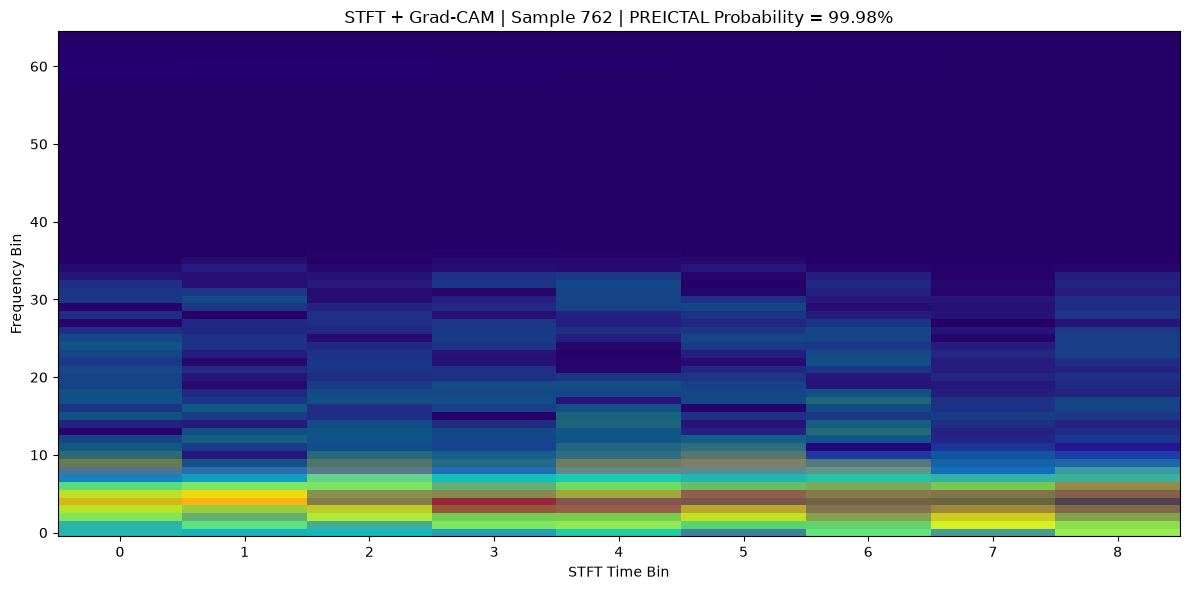

In [67]:
import random
sample_index = random.randint(1,1000)
raw_sample = X_test[sample_index]
stft_sample = make_stft_batch(np.expand_dims(raw_sample, 0))[0]

gradcam, probability = compute_stft_gradcam(
    model, raw_sample, stft_sample
)

print(f"PREICTAL Probability = {probability:.2%}")

plot_stft_gradcam(
    stft_sample,
    gradcam,
    channel=0,
    probability=probability,
    sample_index=sample_index
)


In [68]:
X = data_array
y = label_array
groups = group_array

In [69]:
print("=" * 70)
print("DATA CHECK")
print("=" * 70)

print("X shape      :", X.shape)
print("y shape      :", y.shape)
print("groups shape :", groups.shape)

print("Samples      :", len(X))
print("Labels       :", len(y))
print("Groups       :", len(groups))

print("Patients     :", len(np.unique(groups)))
print("Classes      :", np.unique(y))

assert len(X) == len(y)
assert len(X) == len(groups)

print("Data check PASSED")


DATA CHECK
X shape      : (6127, 640, 14)
y shape      : (6127,)
groups shape : (6127,)
Samples      : 6127
Labels       : 6127
Groups       : 6127
Patients     : 97
Classes      : [0 1]
Data check PASSED


In [85]:
# ============================================================
# PATIENT-INDEPENDENT 5-FOLD TRAINING
# ============================================================

import numpy as np
import tensorflow as tf

from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)



# ------------------------------------------------------------
# 1. GROUP K-FOLD
# ------------------------------------------------------------

gkf = GroupKFold(n_splits=5)


# ------------------------------------------------------------
# 2. RAW EEG SCALING
# ------------------------------------------------------------

def scale_raw_train_val(train_x, val_x):

    scaler = StandardScaler()

    # (samples, time, channels)
    #       ↓
    # (samples*time, channels)

    train_2d = train_x.reshape(
        -1,
        train_x.shape[-1]
    )

    val_2d = val_x.reshape(
        -1,
        val_x.shape[-1]
    )

    # Fit ONLY on training data
    train_scaled = scaler.fit_transform(train_2d)

    # Apply training scaler to validation data
    val_scaled = scaler.transform(val_2d)

    # Restore original shape
    train_scaled = train_scaled.reshape(train_x.shape)
    val_scaled = val_scaled.reshape(val_x.shape)

    return (
        train_scaled.astype(np.float32),
        val_scaled.astype(np.float32),
        scaler
    )


# ------------------------------------------------------------
# 3. STFT SCALING
# ------------------------------------------------------------

def scale_stft_train_val(train_x, val_x):

    # train_x shape:
    # (samples, frequency, time, channels)

    n_train, n_freq, n_time, n_ch = train_x.shape

    # --------------------------------------------------------
    # Rearrange:
    #
    # samples × frequency × time × channels
    #
    #              ↓
    #
    # samples × time × frequency × channels
    #
    #              ↓
    #
    # (samples*time) × (frequency*channels)
    # --------------------------------------------------------

    train_2d = train_x.transpose(
        0, 2, 1, 3
    ).reshape(
        -1,
        n_freq * n_ch
    )

    val_2d = val_x.transpose(
        0, 2, 1, 3
    ).reshape(
        -1,
        n_freq * n_ch
    )

    scaler = StandardScaler()

    # Fit ONLY on training STFT
    train_scaled = scaler.fit_transform(train_2d)

    # Apply same scaler to validation STFT
    val_scaled = scaler.transform(val_2d)

    # Restore STFT shape
    train_scaled = train_scaled.reshape(
        n_train,
        n_time,
        n_freq,
        n_ch
    ).transpose(
        0, 2, 1, 3
    )

    val_scaled = val_scaled.reshape(
        val_x.shape[0],
        n_time,
        n_freq,
        n_ch
    ).transpose(
        0, 2, 1, 3
    )

    return (
        train_scaled.astype(np.float32),
        val_scaled.astype(np.float32),
        scaler
    )


# ============================================================
# 4. RESULTS STORAGE
# ============================================================

fold_results = []


# ============================================================
# 5. PATIENT-INDEPENDENT CROSS VALIDATION
# ============================================================

for fold, (train_idx, val_idx) in enumerate(
    gkf.split(
        X,
        y,
        groups=groups
    ),
    start=1
):

    print("\n")
    print("=" * 70)
    print(f"                    FOLD {fold}")
    print("=" * 70)

    # --------------------------------------------------------
    # TRAIN / VALIDATION SPLIT
    # --------------------------------------------------------

    X_train = X[train_idx]
    X_val = X[val_idx]

    y_train = y[train_idx]
    y_val = y[val_idx]

    print("Training samples   :", len(X_train))
    print("Validation samples :", len(X_val))

    print(
        "Training patients  :",
        len(np.unique(groups[train_idx]))
    )

    print(
        "Validation patients:",
        len(np.unique(groups[val_idx]))
    )

    # --------------------------------------------------------
    # CHECK PATIENT INDEPENDENCE
    # --------------------------------------------------------

    train_patients = set(
        np.unique(groups[train_idx])
    )

    val_patients = set(
        np.unique(groups[val_idx])
    )

    overlap = train_patients.intersection(
        val_patients
    )

    print(
        "Patient overlap    :",
        len(overlap)
    )

    assert len(overlap) == 0, (
        "ERROR: Patient leakage detected!"
    )

    # --------------------------------------------------------
    # STFT
    # --------------------------------------------------------

    print("\nGenerating training STFT...")

    stft_train = make_stft_batch(
        X_train.astype(np.float32)
    )

    print(
        "STFT train shape:",
        stft_train.shape
    )

    print("Generating validation STFT...")

    stft_val = make_stft_batch(
        X_val.astype(np.float32)
    )

    print(
        "STFT validation shape:",
        stft_val.shape
    )

    # --------------------------------------------------------
    # SCALE RAW EEG
    # --------------------------------------------------------

    X_train_scaled, X_val_scaled, raw_scaler = (
        scale_raw_train_val(
            X_train,
            X_val
        )
    )

    # --------------------------------------------------------
    # SCALE STFT
    # --------------------------------------------------------

    stft_train_scaled, stft_val_scaled, stft_scaler = (
        scale_stft_train_val(
            stft_train,
            stft_val
        )
    )

    # --------------------------------------------------------
    # BUILD NEW MODEL FOR THIS FOLD
    # --------------------------------------------------------

    model = build_multimodal_model(
        raw_shape=X_train_scaled.shape[1:],
        stft_shape=stft_train_scaled.shape[1:]
    )

    print("\nModel created for fold", fold)

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    history = model.fit(
        [
            X_train_scaled,
            stft_train_scaled
        ],
        y_train,

        validation_data=(
            [
                X_val_scaled,
                stft_val_scaled
            ],
            y_val
        ),

        epochs=30,

        batch_size=64,

        callbacks=[
            tf.keras.callbacks.EarlyStopping(
                monitor="val_auc",
                mode="max",
                patience=30,
                restore_best_weights=True
            )
        ],

        verbose=1
    )

    # --------------------------------------------------------
    # VALIDATION PREDICTION
    # --------------------------------------------------------

    y_prob = model.predict(
        [
            X_val_scaled,
            stft_val_scaled
        ],
        verbose=0
    ).ravel()

    y_pred = (
        y_prob >= 0.5
    ).astype(int)

    # --------------------------------------------------------
    # METRICS
    # --------------------------------------------------------

    accuracy = accuracy_score(
        y_val,
        y_pred
    )

    precision = precision_score(
        y_val,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        y_pred,
        zero_division=0
    )

    auc = roc_auc_score(
        y_val,
        y_prob
    )

    cm = confusion_matrix(
        y_val,
        y_pred
    )

    # --------------------------------------------------------
    # SAVE RESULTS
    # --------------------------------------------------------

    fold_results.append({
        "Fold": fold,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUROC": auc
    })

    # --------------------------------------------------------
    # PRINT RESULTS
    # --------------------------------------------------------

    print("\n")
    print("-" * 50)
    print(f"FOLD {fold} RESULTS")
    print("-" * 50)

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-score  : {f1:.4f}")
    print(f"AUROC     : {auc:.4f}")

    print("\nConfusion Matrix:")
    print(cm)


# ============================================================
# 6. FINAL 5-FOLD RESULTS
# ============================================================

print("\n")
print("=" * 70)
print("                 5-FOLD FINAL RESULTS")
print("=" * 70)

for result in fold_results:

    print(
        f"Fold {result['Fold']}: "
        f"Accuracy={result['Accuracy']:.4f}, "
        f"Precision={result['Precision']:.4f}, "
        f"Recall={result['Recall']:.4f}, "
        f"F1={result['F1']:.4f}, "
        f"AUROC={result['AUROC']:.4f}"
    )


# ============================================================
# 7. MEAN ± STANDARD DEVIATION
# ============================================================

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "AUROC"
]

print("\n")
print("=" * 70)
print("              MEAN ± STANDARD DEVIATION")
print("=" * 70)

for metric in metrics:

    values = [
        result[metric]
        for result in fold_results
    ]

    mean = np.mean(values)
    std = np.std(values)

    print(
        f"{metric:10s}: "
        f"{mean:.4f} ± {std:.4f}"
    )



                    FOLD 1
Training samples   : 4902
Validation samples : 1225
Training patients  : 78
Validation patients: 19
Patient overlap    : 0

Generating training STFT...
STFT train shape: (4902, 65, 9, 14)
Generating validation STFT...
STFT validation shape: (1225, 65, 9, 14)

Model created for fold 1
Epoch 1/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - accuracy: 0.5671 - auc: 0.5920 - loss: 0.6841 - val_accuracy: 0.5771 - val_auc: 0.6564 - val_loss: 0.6708
Epoch 2/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.6601 - auc: 0.7089 - loss: 0.6268 - val_accuracy: 0.7371 - val_auc: 0.8178 - val_loss: 0.5951
Epoch 3/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.7970 - auc: 0.8706 - loss: 0.4572 - val_accuracy: 0.8416 - val_auc: 0.9179 - val_loss: 0.3720
Epoch 4/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.8439 - auc: 0.9097 - loss: 0.3782 - val_accuracy: 0.8490 - val_auc: 0.9419 - val_loss: 0.3549
Epoch 5/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/ste

PREICTAL Probability = 97.22%


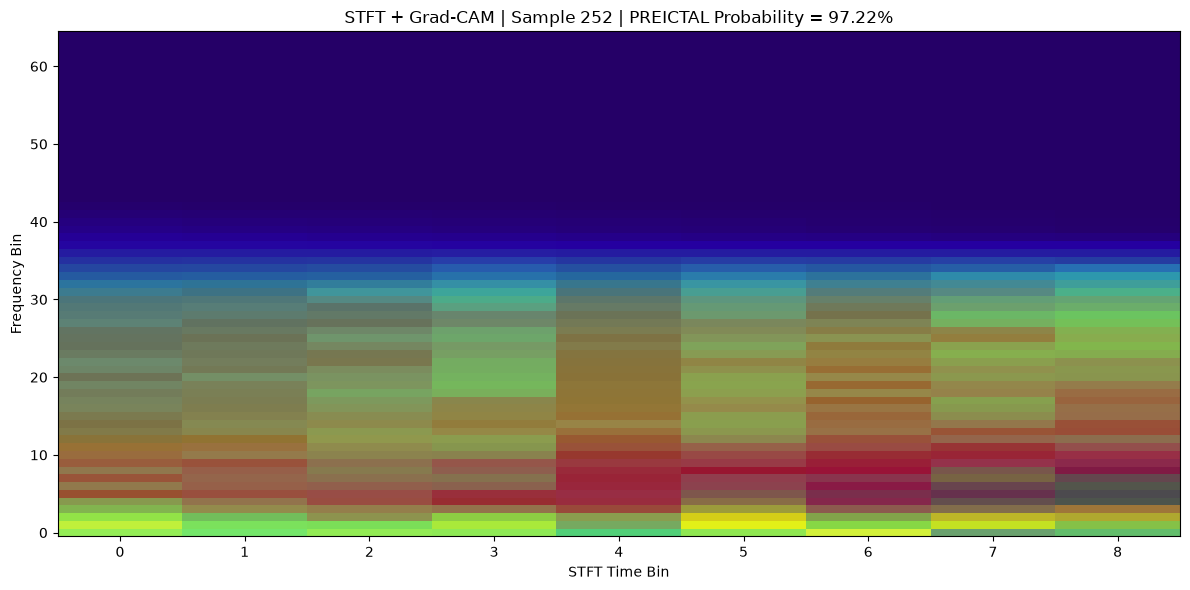

In [86]:
import random
sample_index = random.randint(1,1000)
raw_sample = X_test[sample_index]
stft_sample = make_stft_batch(np.expand_dims(raw_sample, 0))[0]

gradcam, probability = compute_stft_gradcam(
    model, raw_sample, stft_sample
)

print(f"PREICTAL Probability = {probability:.2%}")

plot_stft_gradcam(
    stft_sample,
    gradcam,
    channel=0,
    probability=probability,
    sample_index=sample_index
)


# all channel grad cam

                    GRAD-CAM SETUP
Model available          : True
X_train_scaled shape     : (4892, 640, 14)
stft_train_scaled shape  : (4892, 65, 9, 14)
y_train shape            : (4892,)

              RANDOM TRAINING EEG SAMPLE
Total training samples : 4892
Selected sample index  : 106
Raw EEG sample shape   : (1, 640, 14)
STFT sample shape      : (1, 65, 9, 14)
Number of EEG channels : 14
Actual label           : 0

EEG channel names:
  Channel 00 : AF3
  Channel 01 : AF4
  Channel 02 : F3
  Channel 03 : F4
  Channel 04 : F7
  Channel 05 : F8
  Channel 06 : FC5
  Channel 07 : FC6
  Channel 08 : O1
  Channel 09 : O2
  Channel 10 : P7
  Channel 11 : P8
  Channel 12 : T7
  Channel 13 : T8

                    MODEL PREDICTION
Sample index          : 106
Actual label          : 0
Predicted label       : 0
Epilepsy probability  : 3.22%

                    GRAD-CAM LAYER
Layer name   : stft_gradcam_activation
Layer output : (None, 16, 2, 64)

                    GRADIENT INFORMATION
Ac

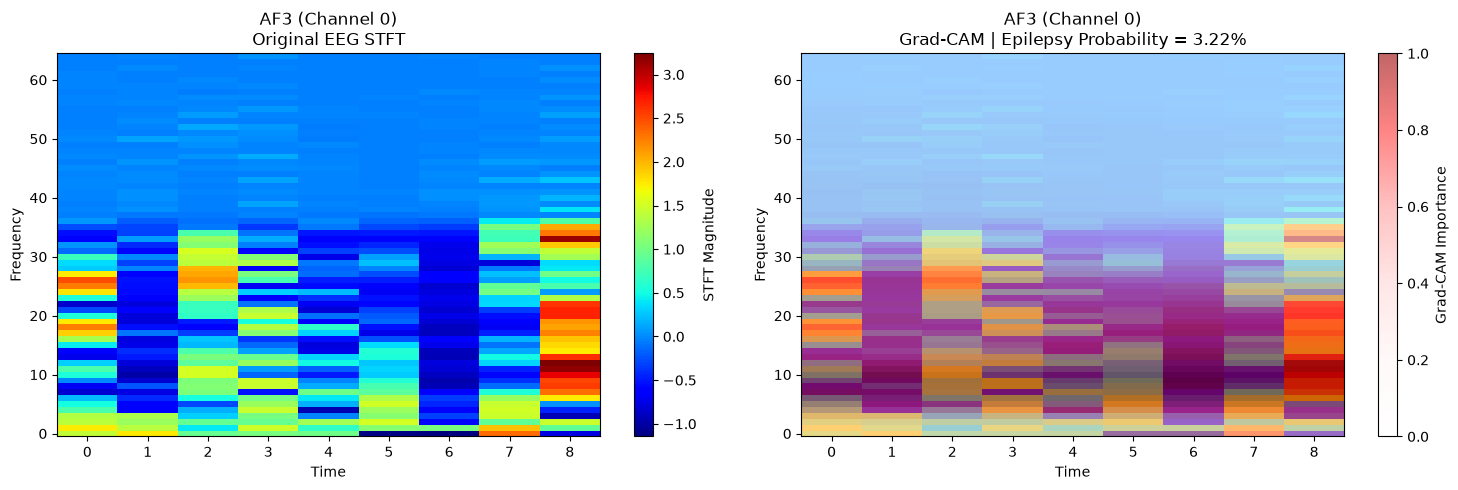

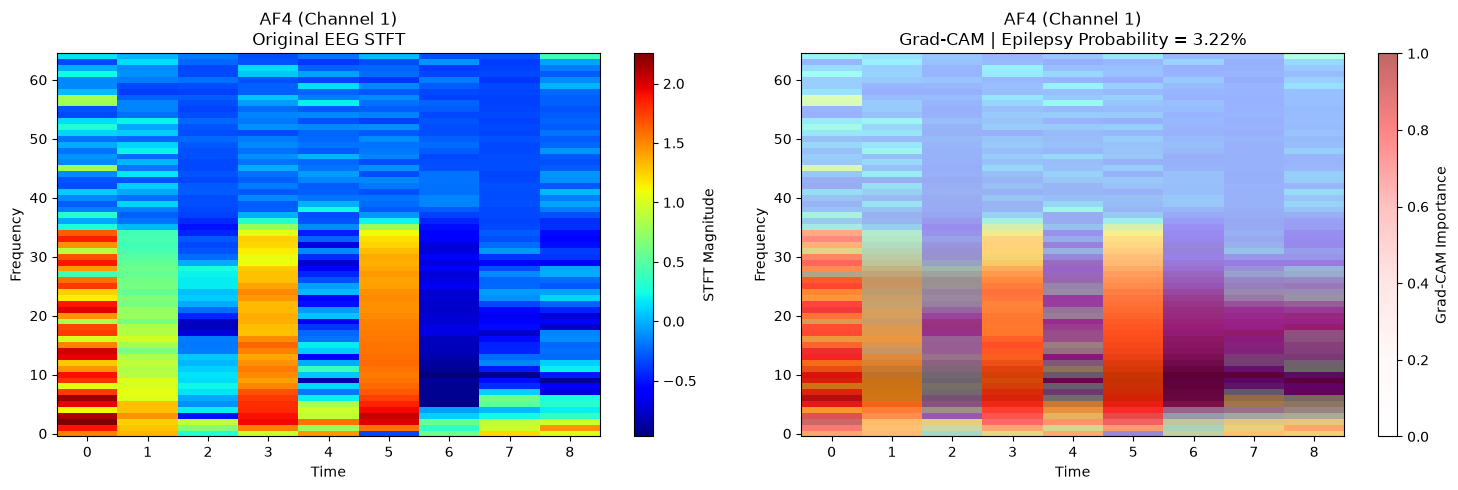

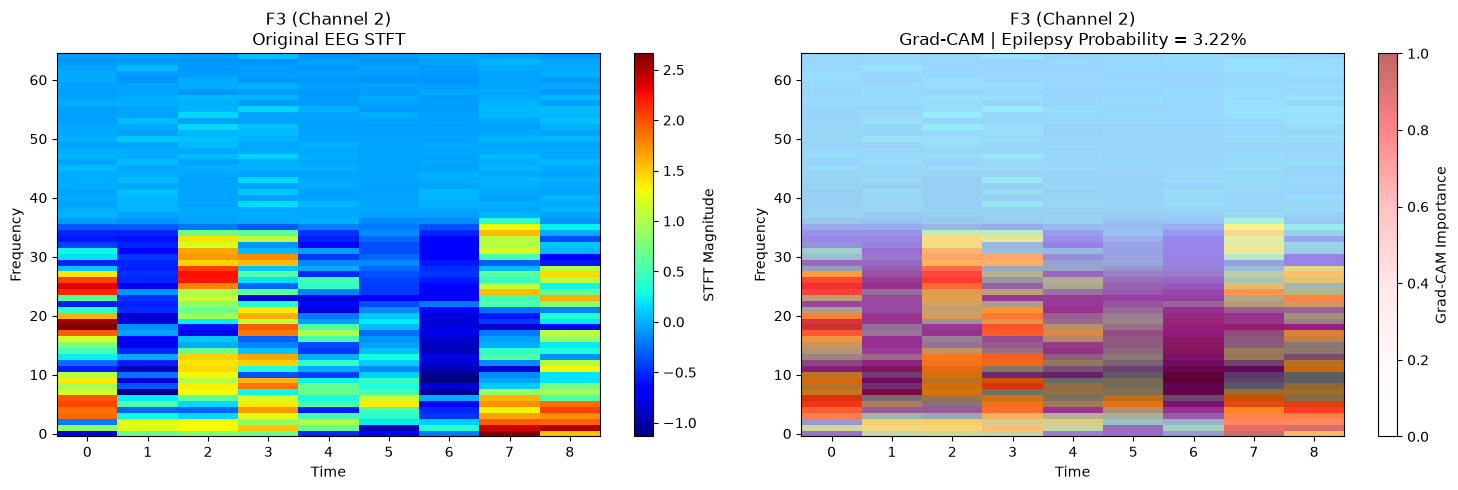

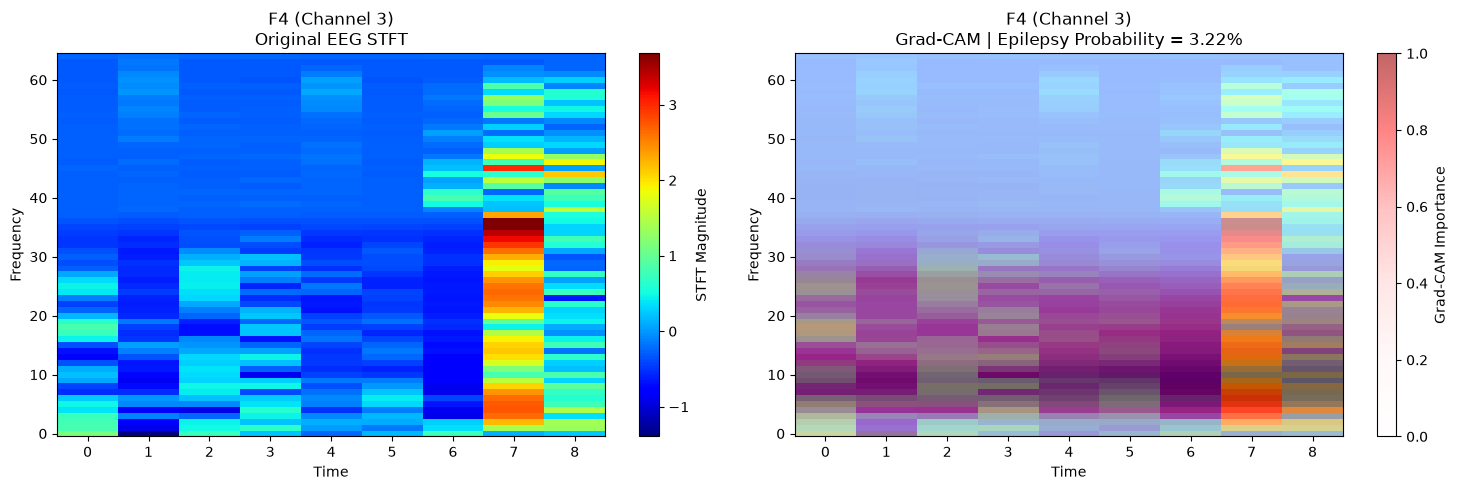

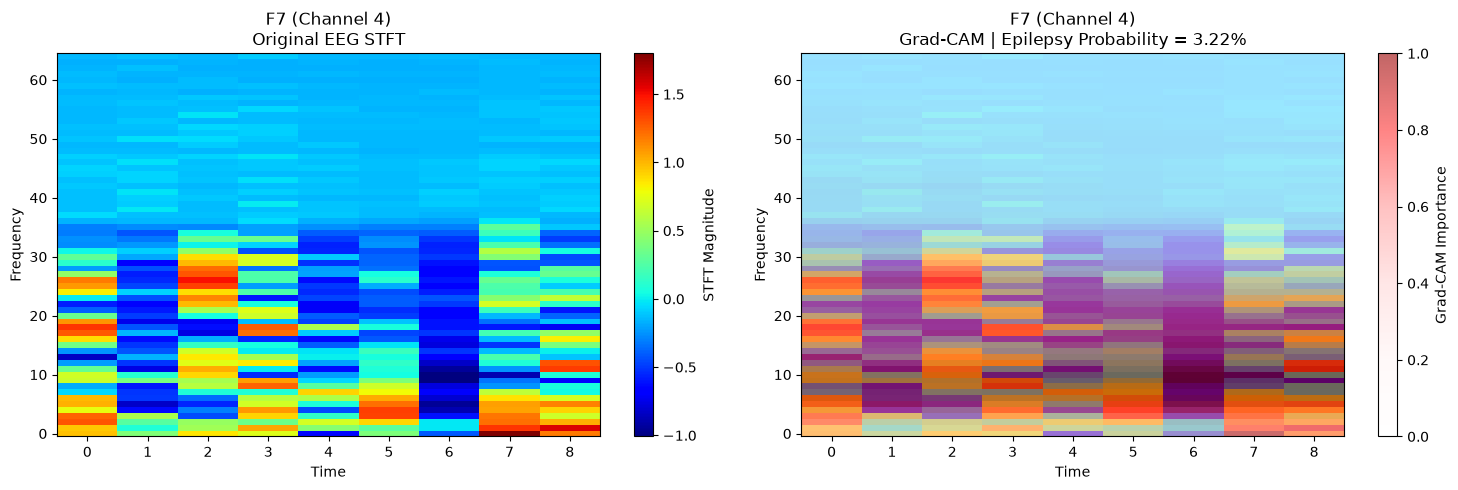

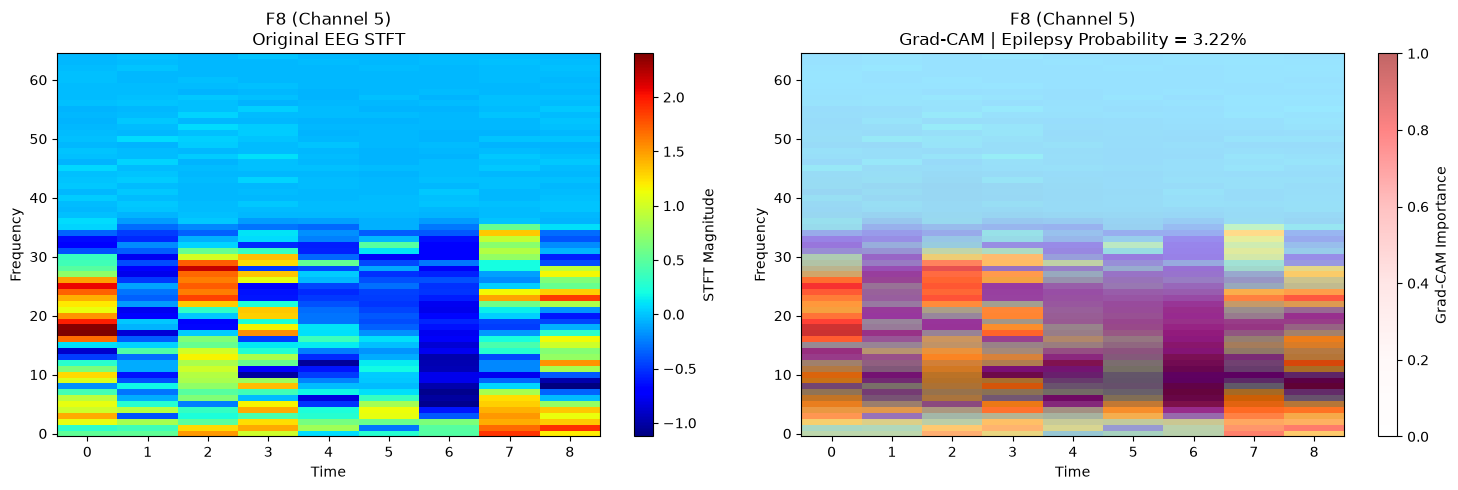

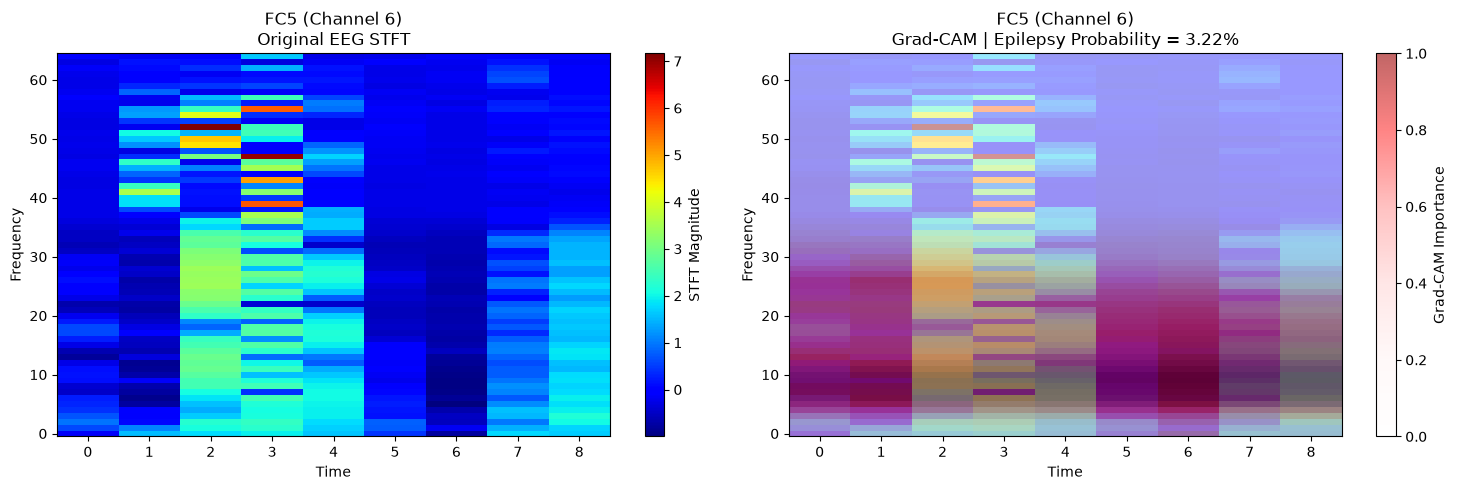

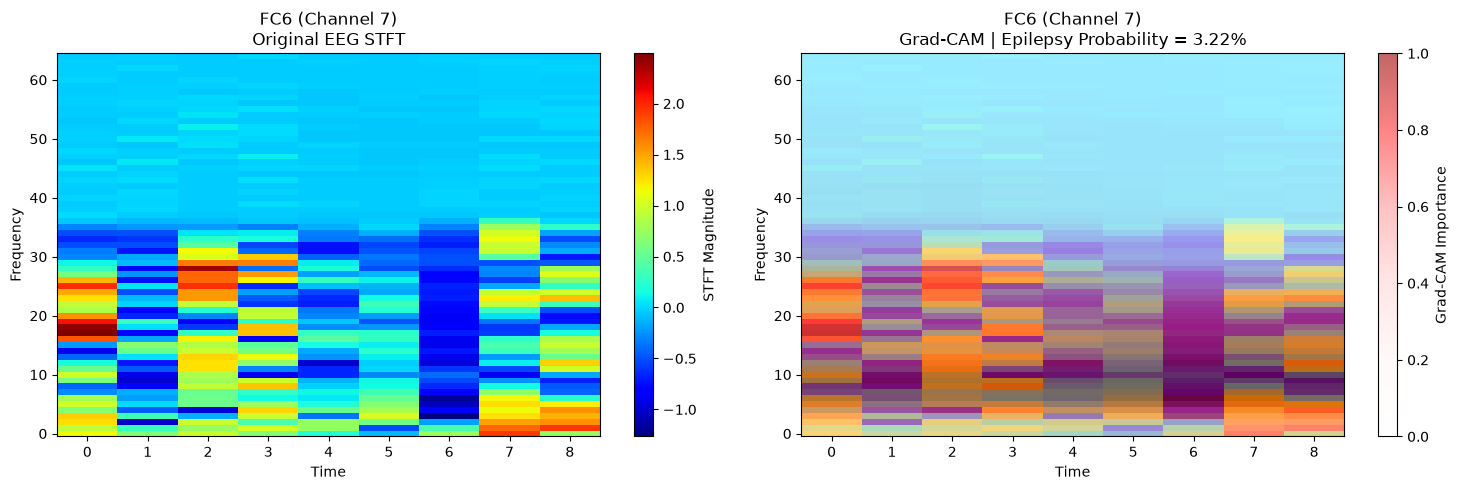

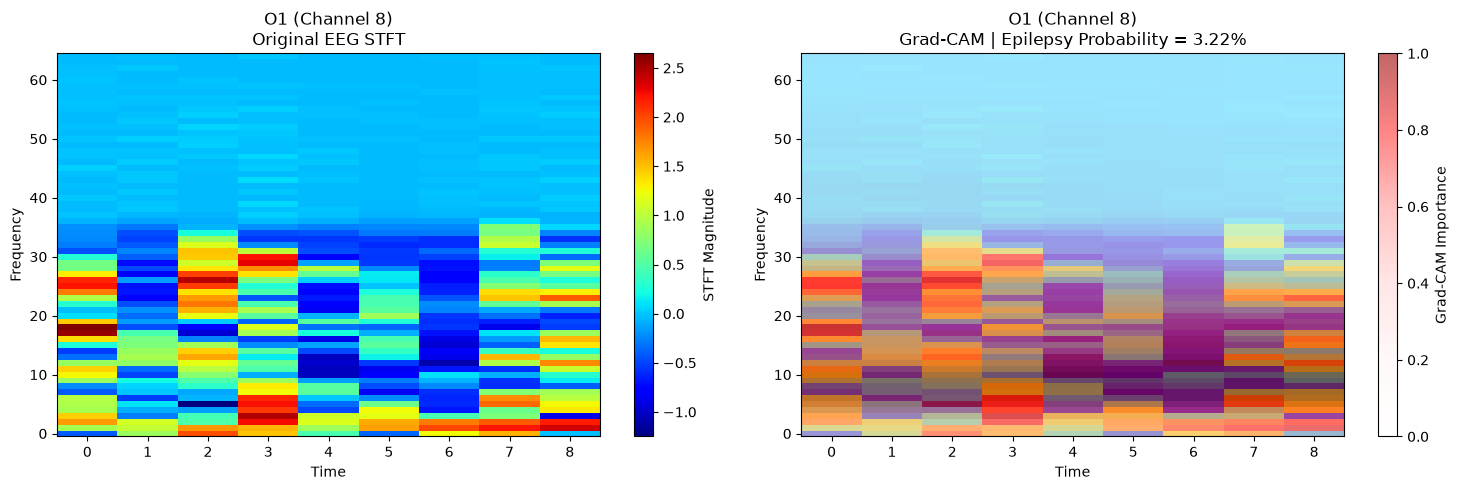

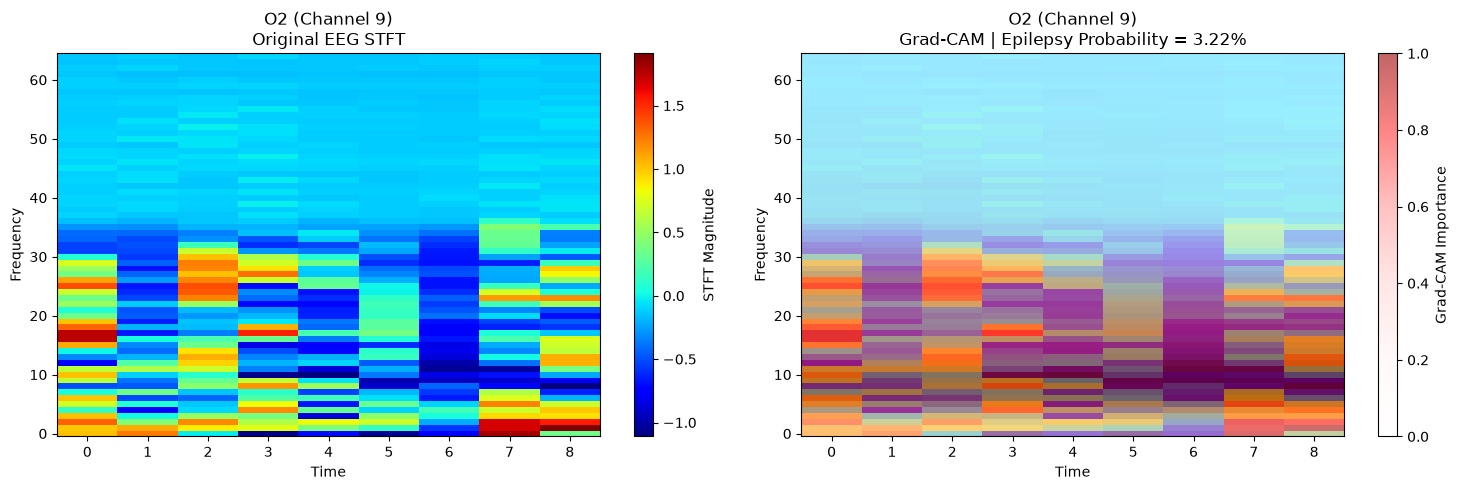

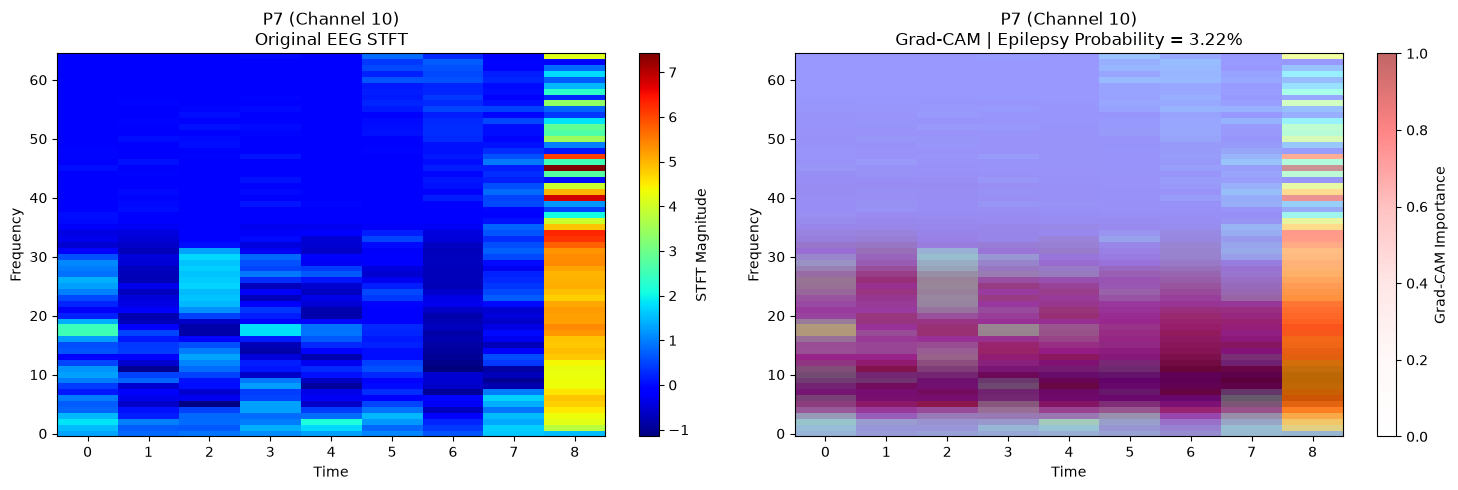

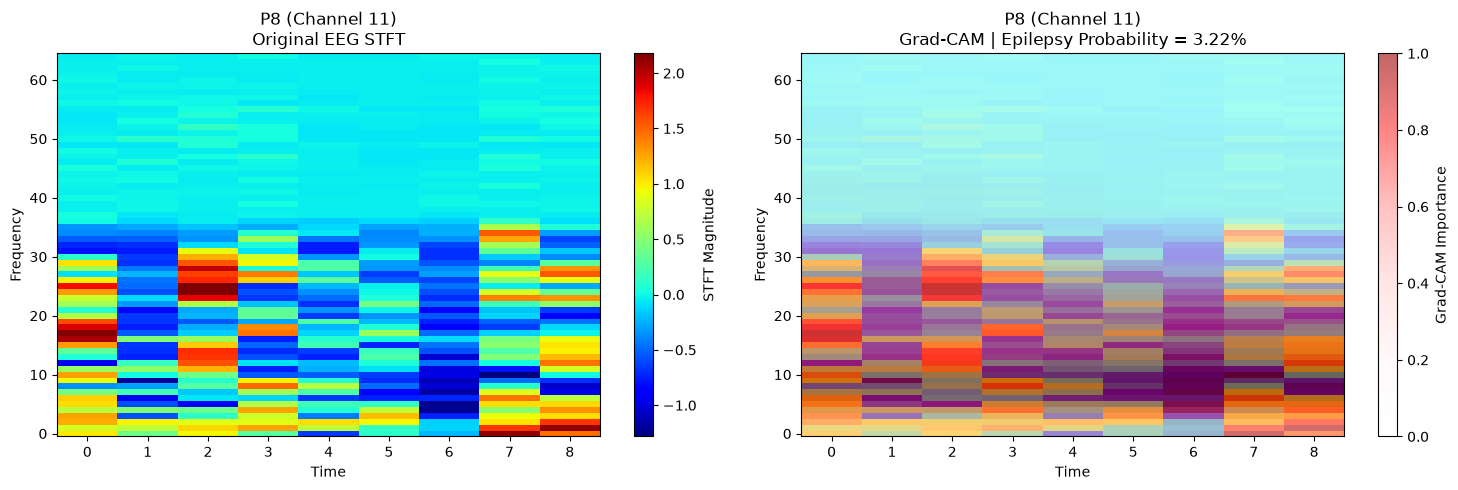

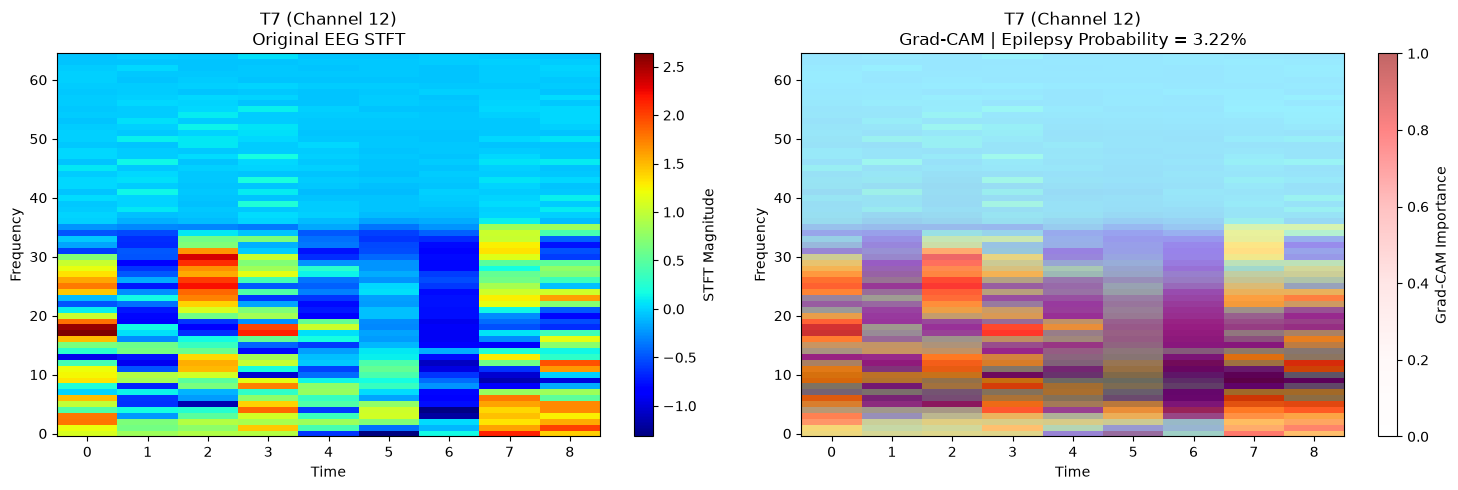

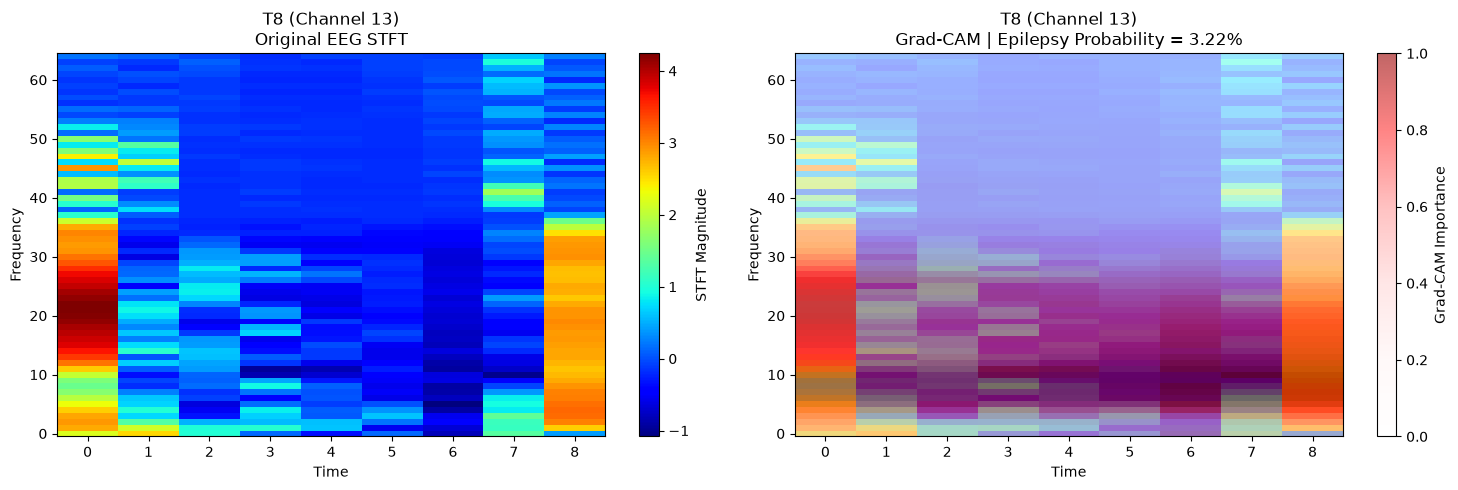


                     FINAL SUMMARY
Random sample index   : 106
Number of channels    : 14
Actual label          : 0
Predicted label       : 0
Epilepsy probability  : 3.22%
Grad-CAM shape        : (65, 9)
Grad-CAM display range: 0 to 1


In [ ]:
# ============================================================
# STFT GRAD-CAM
# RANDOM TRAINING SAMPLE FROM SELECTED FOLD
# ============================================================

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import random

from matplotlib.colors import LinearSegmentedColormap


# ============================================================
# 1. SELECT FOLD
# ============================================================

GRADCAM_FOLD = 4

fold_idx = GRADCAM_FOLD - 1


# ============================================================
# 2. GET CORRECT FOLD MODEL + DATA
# ============================================================

gradcam_model = fold_models[fold_idx]

gradcam_raw = fold_train_data[fold_idx]["raw"]

gradcam_stft = fold_train_data[fold_idx]["stft"]

gradcam_y = fold_train_labels[fold_idx]


print("=" * 70)
print("                    GRAD-CAM SETUP")
print("=" * 70)

print(
    "Selected fold           :",
    GRADCAM_FOLD
)

print(
    "Training samples        :",
    len(gradcam_raw)
)

print(
    "Raw training shape      :",
    gradcam_raw.shape
)

print(
    "STFT training shape     :",
    gradcam_stft.shape
)

print(
    "Training labels shape   :",
    gradcam_y.shape
)


# ============================================================
# 3. SELECT RANDOM SAMPLE
# ============================================================

sample_index = random.randint(
    0,
    len(gradcam_raw) - 1
)


raw_sample = gradcam_raw[
    sample_index:sample_index + 1
]

stft_sample = gradcam_stft[
    sample_index:sample_index + 1
]


actual_label = int(
    gradcam_y[sample_index]
)


num_channels = stft_sample.shape[-1]


print()
print("=" * 70)
print("              SELECTED EEG SAMPLE")
print("=" * 70)

print(
    "Sample index           :",
    sample_index
)

print(
    "Raw sample shape       :",
    raw_sample.shape
)

print(
    "STFT sample shape      :",
    stft_sample.shape
)

print(
    "Number of channels     :",
    num_channels
)

print(
    "Actual label           :",
    actual_label
)


# ============================================================
# 4. CHANNEL NAMES
# ============================================================

try:

    channel_names = (
        Epilepsy2[0]
        .columns
        .tolist()
    )

except Exception:

    channel_names = [
        f"Channel {i}"
        for i in range(num_channels)
    ]


if len(channel_names) != num_channels:

    channel_names = [
        f"Channel {i}"
        for i in range(num_channels)
    ]


# ============================================================
# 5. MODEL PREDICTION
# ============================================================

prediction = gradcam_model.predict(
    [
        raw_sample,
        stft_sample
    ],
    verbose=0
)


probability = float(
    prediction[0, 0]
)


predicted_label = int(
    probability >= 0.5
)


print()
print("=" * 70)
print("                    MODEL PREDICTION")
print("=" * 70)

print(
    "Actual label           :",
    actual_label
)

print(
    "Predicted label        :",
    predicted_label
)

print(
    f"Epilepsy probability  : {probability:.2%}"
)


# ============================================================
# 6. FIND GRAD-CAM LAYER
# ============================================================

gradcam_layer_name = "stft_gradcam_activation"


gradcam_layer = gradcam_model.get_layer(
    gradcam_layer_name
)


print()
print("=" * 70)
print("                    GRAD-CAM LAYER")
print("=" * 70)

print(
    "Layer:",
    gradcam_layer.name
)

print(
    "Output shape:",
    gradcam_layer.output.shape
)


# ============================================================
# 7. CREATE GRAD-CAM MODEL
# ============================================================

grad_model = tf.keras.models.Model(

    inputs=gradcam_model.inputs,

    outputs=[
        gradcam_layer.output,
        gradcam_model.output
    ]
)


# ============================================================
# 8. CALCULATE GRADIENT
# ============================================================

with tf.GradientTape() as tape:

    conv_outputs, predictions = grad_model(
        [
            raw_sample,
            stft_sample
        ],
        training=False
    )

    target_prediction = predictions[:, 0]


grads = tape.gradient(
    target_prediction,
    conv_outputs
)


if grads is None:

    raise RuntimeError(
        "Gradients are None. "
        "The Grad-CAM layer may not be connected "
        "to the prediction output."
    )


print()
print("=" * 70)
print("                    GRADIENT")
print("=" * 70)

print(
    "Activation shape:",
    conv_outputs.shape
)

print(
    "Gradient shape  :",
    grads.shape
)


# ============================================================
# 9. GLOBAL AVERAGE POOLING
# ============================================================

if len(conv_outputs.shape) == 3:

    # (batch, time, features)

    pooled_grads = tf.reduce_mean(
        grads,
        axis=1
    )

    activation_sample = conv_outputs[0]

    pooled_grads_sample = pooled_grads[0]

    heatmap = tf.reduce_sum(
        activation_sample *
        pooled_grads_sample,
        axis=-1
    )


elif len(conv_outputs.shape) == 4:

    # (batch, frequency, time, features)

    pooled_grads = tf.reduce_mean(
        grads,
        axis=(1, 2)
    )

    activation_sample = conv_outputs[0]

    pooled_grads_sample = pooled_grads[0]

    heatmap = tf.reduce_sum(
        activation_sample *
        pooled_grads_sample,
        axis=-1
    )


else:

    raise ValueError(
        f"Unsupported activation shape: "
        f"{conv_outputs.shape}"
    )


# ============================================================
# 10. POSITIVE CONTRIBUTIONS ONLY
# ============================================================

heatmap = tf.maximum(
    heatmap,
    0
)


# ============================================================
# 11. NORMALIZE
# ============================================================

heatmap_max = tf.reduce_max(
    heatmap
)


heatmap = heatmap / (
    heatmap_max + 1e-8
)


heatmap = heatmap.numpy()


print()
print("=" * 70)
print("                    HEATMAP")
print("=" * 70)

print(
    "Heatmap shape:",
    heatmap.shape
)

print(
    "Minimum:",
    np.min(heatmap)
)

print(
    "Maximum:",
    np.max(heatmap)
)


# ============================================================
# 12. RESIZE TO STFT DIMENSIONS
# ============================================================

stft_frequency = stft_sample.shape[1]

stft_time = stft_sample.shape[2]


if heatmap.ndim == 1:

    heatmap_resized = tf.image.resize(

        heatmap[np.newaxis, :, np.newaxis],

        (
            stft_frequency,
            stft_time
        )
    )

    heatmap_resized = (
        heatmap_resized
        .numpy()
        .squeeze()
    )


elif heatmap.ndim == 2:

    heatmap_resized = tf.image.resize(

        heatmap[..., np.newaxis],

        (
            stft_frequency,
            stft_time
        )
    )

    heatmap_resized = (
        heatmap_resized
        .numpy()
        .squeeze()
    )


else:

    raise ValueError(
        f"Unexpected heatmap shape: {heatmap.shape}"
    )


# ============================================================
# 13. COLORMAP
# ============================================================

gradcam_cmap = LinearSegmentedColormap.from_list(

    "gradcam_red",

    [
        (0.00, "#ffffff"),
        (0.20, "#fff5f5"),
        (0.40, "#ffd6d6"),
        (0.60, "#ff9999"),
        (0.80, "#ff3333"),
        (1.00, "#990000")
    ]
)


# ============================================================
# 14. PLOT ALL CHANNELS
# ============================================================

print()
print("=" * 70)
print("                 GENERATING CHANNEL PLOTS")
print("=" * 70)


for channel in range(num_channels):

    stft_image = stft_sample[
        0,
        :,
        :,
        channel
    ]


    stft_image = np.asarray(
        stft_image,
        dtype=np.float32
    )


    fig, axes = plt.subplots(
        1,
        2,
        figsize=(15, 5)
    )


    # ========================================================
    # ORIGINAL STFT
    # ========================================================

    im_original = axes[0].imshow(

        stft_image,

        aspect="auto",

        origin="lower",

        cmap="jet"
    )


    axes[0].set_xlabel("Time")

    axes[0].set_ylabel("Frequency")

    axes[0].set_title(

        f"{channel_names[channel]} "
        f"(Channel {channel})\n"
        f"Original EEG STFT"
    )


    fig.colorbar(
        im_original,
        ax=axes[0],
        label="STFT Magnitude"
    )


    # ========================================================
    # GRAD-CAM
    # ========================================================

    axes[1].imshow(

        stft_image,

        aspect="auto",

        origin="lower",

        cmap="jet"
    )


    im_cam = axes[1].imshow(

        heatmap_resized,

        aspect="auto",

        origin="lower",

        cmap=gradcam_cmap,

        alpha=0.60,

        vmin=0,

        vmax=1
    )


    axes[1].set_xlabel("Time")

    axes[1].set_ylabel("Frequency")

    axes[1].set_title(

        f"{channel_names[channel]} "
        f"(Channel {channel})\n"
        f"Grad-CAM | "
        f"Epilepsy Probability = "
        f"{probability:.2%}"
    )


    fig.colorbar(

        im_cam,

        ax=axes[1],

        label="Grad-CAM Importance"
    )


    plt.tight_layout()

    plt.show()


# ============================================================
# 15. FINAL SUMMARY
# ============================================================

print()
print("=" * 70)
print("                     FINAL SUMMARY")
print("=" * 70)

print(
    "Fold                   :",
    GRADCAM_FOLD
)

print(
    "Random sample index    :",
    sample_index
)

print(
    "Actual label           :",
    actual_label
)

print(
    "Predicted label        :",
    predicted_label
)

print(
    f"Epilepsy probability   : {probability:.2%}"
)

print(
    "Number of channels     :",
    num_channels
)

print(
    "Grad-CAM shape         :",
    heatmap_resized.shape
)

print("=" * 70)


                    DATA INFORMATION
X shape      : (6127, 640, 14)
y shape      : (6127,)
groups shape : (6127,)
Total samples: 6127
Total patients: 97
Class 0 samples: 3042
Class 1 samples: 3085


                    FOLD 1
Training samples   : 4902
Validation samples : 1225
Training patients  : 78
Validation patients: 19

Training class distribution:
  Control (0): 2447
  Epilepsy (1): 2455
Validation class distribution:
  Control (0): 595
  Epilepsy (1): 630

Patient overlap: 0

Generating training STFT...
STFT train shape: (4902, 65, 9, 14)
Generating validation STFT...
STFT validation shape: (1225, 65, 9, 14)

Scaling RAW EEG...
Scaling STFT...

Scaled RAW train: (4902, 640, 14)
Scaled RAW val  : (1225, 640, 14)
Scaled STFT train: (4902, 65, 9, 14)
Scaled STFT val  : (1225, 65, 9, 14)

Building model...

Model created for fold 1
Epoch 1/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 11s 74ms/step - accuracy: 0.5386 - auc: 0.5553 - loss: 0.6921 - val_accuracy: 0.5641 - val_auc: 0.5853 - val_loss: 0

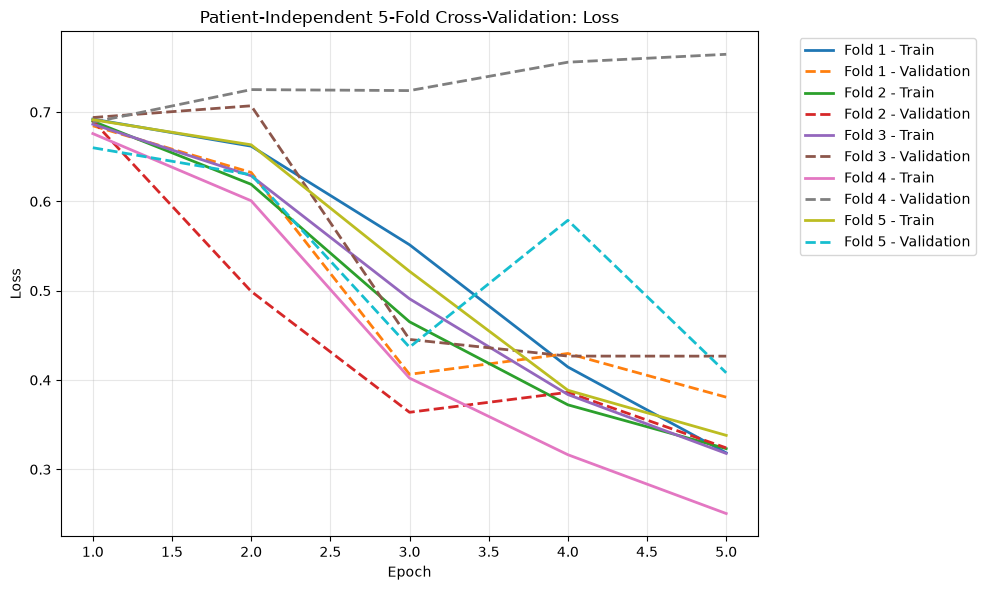

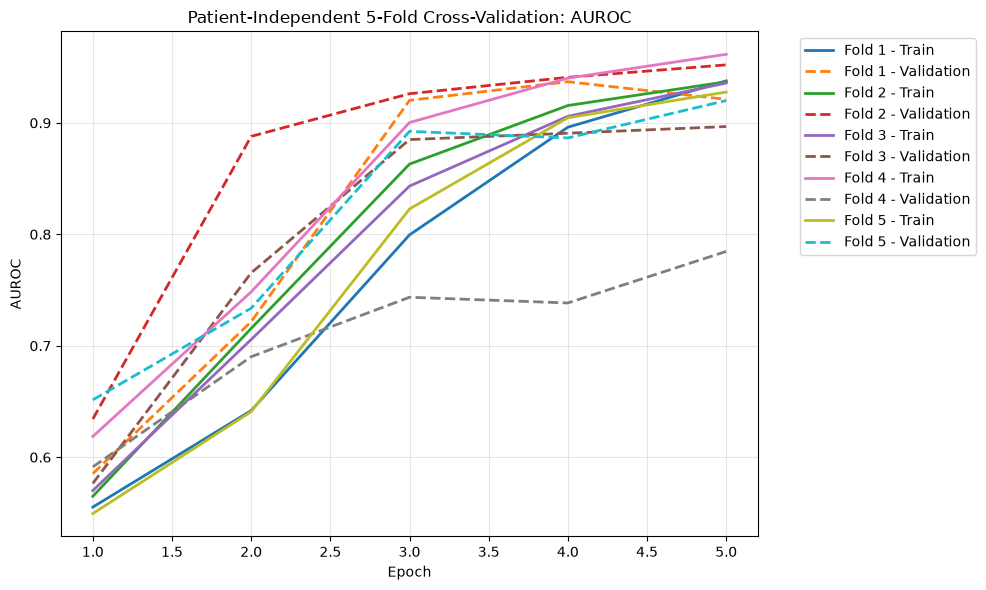

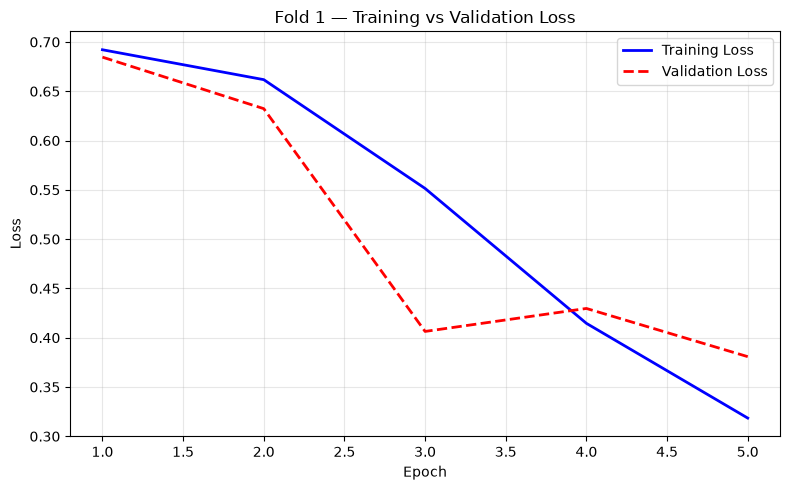

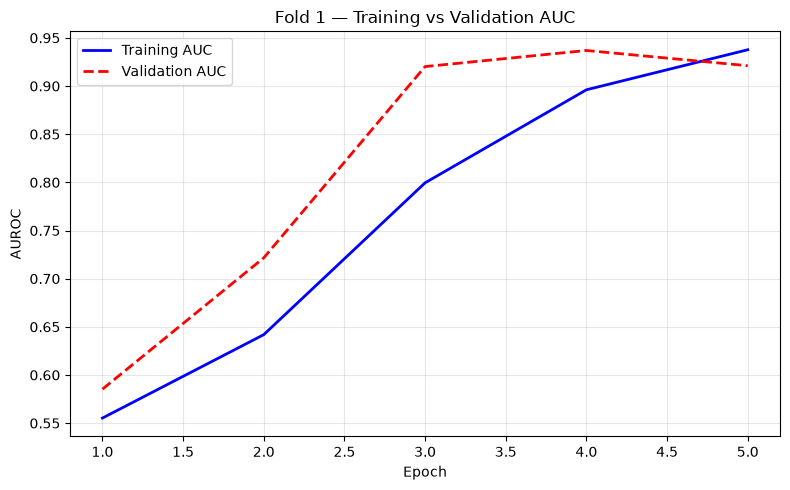

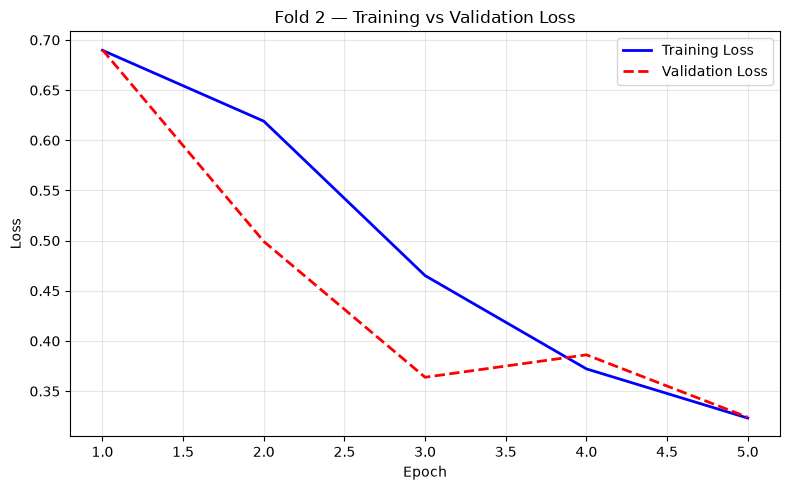

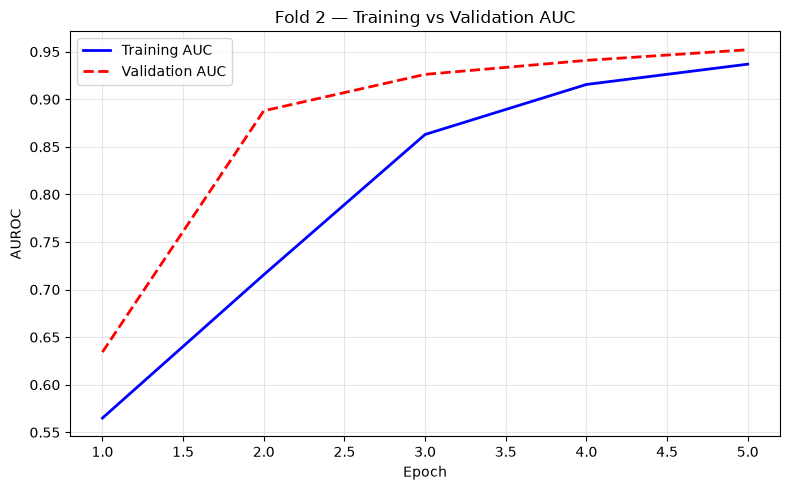

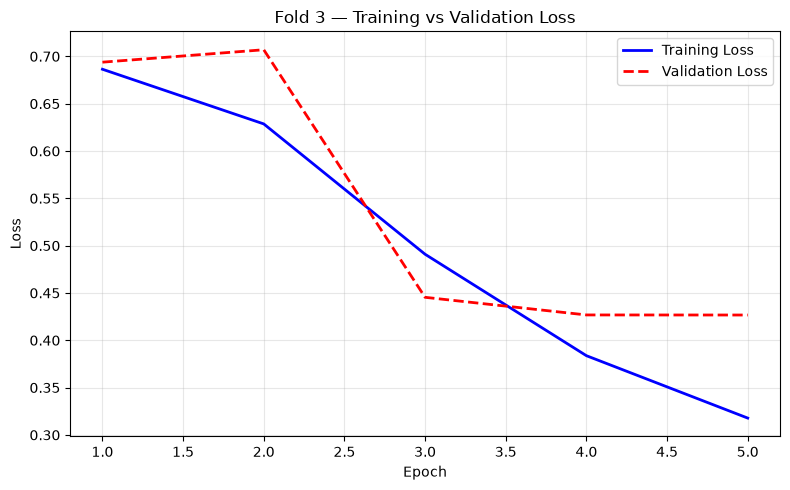

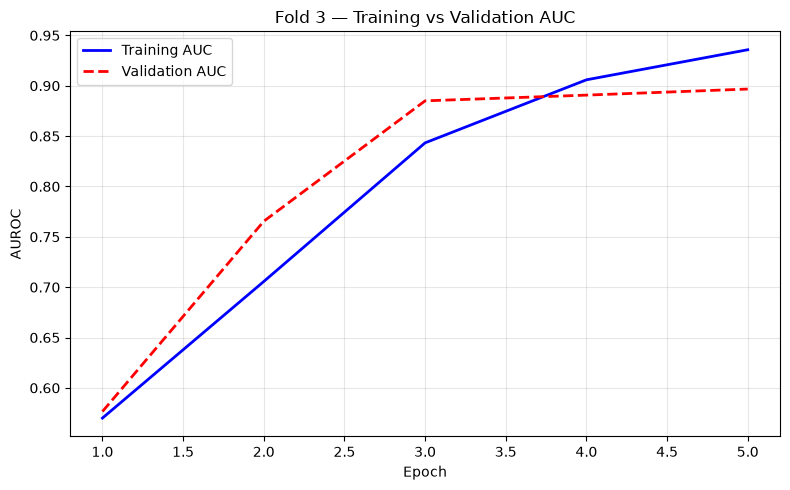

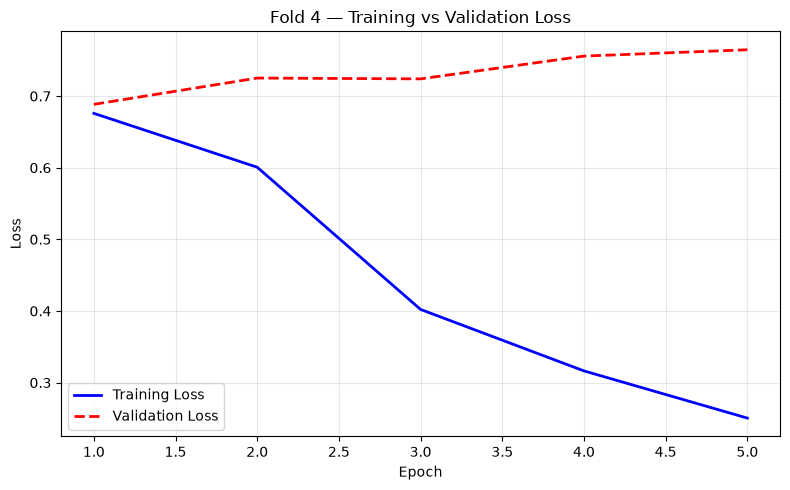

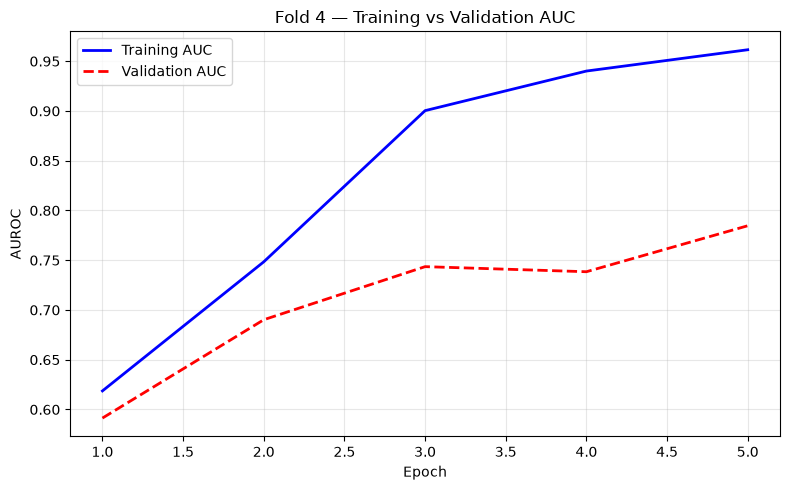

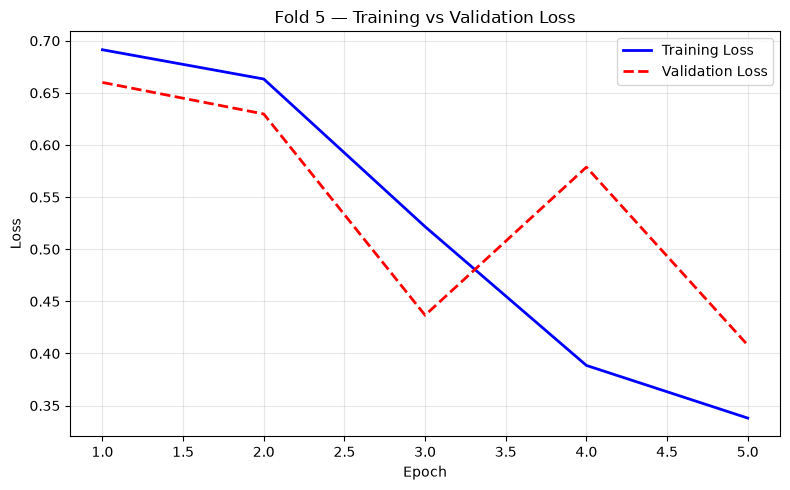

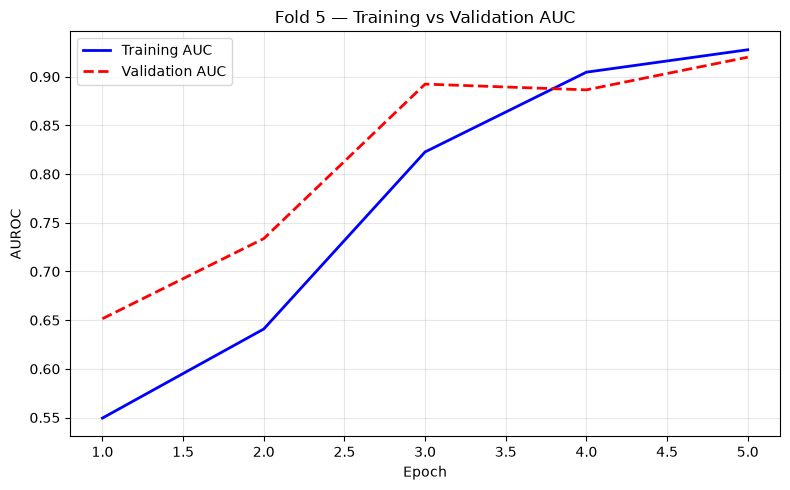



                 BEST EPOCH INFORMATION
Fold 1: Best Epoch = 4, Best Validation AUC = 0.9369
Fold 2: Best Epoch = 5, Best Validation AUC = 0.9520
Fold 3: Best Epoch = 5, Best Validation AUC = 0.8967
Fold 4: Best Epoch = 5, Best Validation AUC = 0.7846
Fold 5: Best Epoch = 5, Best Validation AUC = 0.9200


                 CROSS-VALIDATION COMPLETE
Models stored       : 5
Histories stored    : 5
Fold results stored : 5


In [89]:
# ============================================================
# PATIENT-INDEPENDENT 5-FOLD CROSS-VALIDATION
# MULTIMODAL EEG MODEL
# RAW EEG + STFT
# ============================================================

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)


# ============================================================
# 0. DATA
# ============================================================

X = data_array
y = label_array
groups = group_array


# Make sure arrays are NumPy arrays
X = np.asarray(X)
y = np.asarray(y)
groups = np.asarray(groups)


print("=" * 70)
print("                    DATA INFORMATION")
print("=" * 70)

print("X shape      :", X.shape)
print("y shape      :", y.shape)
print("groups shape :", groups.shape)

print(
    "Total samples:",
    len(X)
)

print(
    "Total patients:",
    len(np.unique(groups))
)

print(
    "Class 0 samples:",
    np.sum(y == 0)
)

print(
    "Class 1 samples:",
    np.sum(y == 1)
)


# ============================================================
# 1. CHECK DATA CONSISTENCY
# ============================================================

assert len(X) == len(y), \
    "X and y have different numbers of samples!"

assert len(X) == len(groups), \
    "X and groups have different numbers of samples!"

assert len(np.unique(groups)) >= 5, \
    "Need at least 5 unique patients for 5-fold GroupKFold!"


# ============================================================
# 2. GROUP K-FOLD
# ============================================================

gkf = GroupKFold(
    n_splits=5
)


# ============================================================
# 3. RAW EEG SCALING
# ============================================================

def scale_raw_train_val(
    train_x,
    val_x
):

    """
    Scale RAW EEG.

    Input shape:
        (samples, time, channels)

    Scaling is performed channel-wise.

    IMPORTANT:
        scaler is fitted ONLY on training data.
    """

    scaler = StandardScaler()


    # --------------------------------------------------------
    # Reshape
    #
    # (samples, time, channels)
    #
    # ->
    #
    # (samples*time, channels)
    # --------------------------------------------------------

    train_2d = train_x.reshape(
        -1,
        train_x.shape[-1]
    )

    val_2d = val_x.reshape(
        -1,
        val_x.shape[-1]
    )


    # --------------------------------------------------------
    # FIT ONLY ON TRAINING DATA
    # --------------------------------------------------------

    train_scaled = scaler.fit_transform(
        train_2d
    )


    # --------------------------------------------------------
    # TRANSFORM VALIDATION USING TRAINING SCALER
    # --------------------------------------------------------

    val_scaled = scaler.transform(
        val_2d
    )


    # --------------------------------------------------------
    # RESTORE ORIGINAL SHAPE
    # --------------------------------------------------------

    train_scaled = train_scaled.reshape(
        train_x.shape
    )

    val_scaled = val_scaled.reshape(
        val_x.shape
    )


    return (
        train_scaled.astype(np.float32),
        val_scaled.astype(np.float32),
        scaler
    )


# ============================================================
# 4. STFT SCALING
# ============================================================

def scale_stft_train_val(
    train_x,
    val_x
):

    """
    Scale STFT.

    Input:
        (samples, frequency, time, channels)

    Scaling is performed across:
        frequency × channel

    for each time point.

    IMPORTANT:
        scaler is fitted ONLY on training STFT.
    """

    n_train = train_x.shape[0]
    n_freq = train_x.shape[1]
    n_time = train_x.shape[2]
    n_ch = train_x.shape[3]


    # --------------------------------------------------------
    # TRAIN
    #
    # samples × frequency × time × channels
    #
    # ->
    #
    # samples × time × frequency × channels
    #
    # ->
    #
    # (samples*time) × (frequency*channels)
    # --------------------------------------------------------

    train_2d = train_x.transpose(
        0,
        2,
        1,
        3
    ).reshape(
        -1,
        n_freq * n_ch
    )


    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    val_2d = val_x.transpose(
        0,
        2,
        1,
        3
    ).reshape(
        -1,
        n_freq * n_ch
    )


    # --------------------------------------------------------
    # CREATE SCALER
    # --------------------------------------------------------

    scaler = StandardScaler()


    # --------------------------------------------------------
    # FIT ONLY ON TRAINING STFT
    # --------------------------------------------------------

    train_scaled = scaler.fit_transform(
        train_2d
    )


    # --------------------------------------------------------
    # TRANSFORM VALIDATION
    # --------------------------------------------------------

    val_scaled = scaler.transform(
        val_2d
    )


    # --------------------------------------------------------
    # RESTORE TRAINING SHAPE
    # --------------------------------------------------------

    train_scaled = train_scaled.reshape(
        n_train,
        n_time,
        n_freq,
        n_ch
    ).transpose(
        0,
        2,
        1,
        3
    )


    # --------------------------------------------------------
    # RESTORE VALIDATION SHAPE
    # --------------------------------------------------------

    val_scaled = val_scaled.reshape(
        val_x.shape[0],
        n_time,
        n_freq,
        n_ch
    ).transpose(
        0,
        2,
        1,
        3
    )


    return (
        train_scaled.astype(np.float32),
        val_scaled.astype(np.float32),
        scaler
    )


# ============================================================
# 5. STORAGE
# ============================================================

fold_results = []

fold_histories = []

fold_models = []

fold_train_data = []

fold_val_data = []

fold_train_labels = []

fold_val_labels = []

fold_train_indices = []

fold_val_indices = []


# ============================================================
# 6. 5-FOLD PATIENT-INDEPENDENT TRAINING
# ============================================================

for fold, (train_idx, val_idx) in enumerate(
    gkf.split(
        X,
        y,
        groups=groups
    ),
    start=1
):


    print("\n")
    print("=" * 70)
    print(
        f"                    FOLD {fold}"
    )
    print("=" * 70)


    # ========================================================
    # SAVE INDICES
    # ========================================================

    fold_train_indices.append(
        train_idx
    )

    fold_val_indices.append(
        val_idx
    )


    # ========================================================
    # TRAIN / VALIDATION SPLIT
    # ========================================================

    X_train = X[
        train_idx
    ]

    X_val = X[
        val_idx
    ]


    y_train = y[
        train_idx
    ]

    y_val = y[
        val_idx
    ]


    groups_train = groups[
        train_idx
    ]

    groups_val = groups[
        val_idx
    ]


    # ========================================================
    # BASIC INFORMATION
    # ========================================================

    print(
        "Training samples   :",
        len(X_train)
    )

    print(
        "Validation samples :",
        len(X_val)
    )

    print(
        "Training patients  :",
        len(np.unique(groups_train))
    )

    print(
        "Validation patients:",
        len(np.unique(groups_val))
    )


    # ========================================================
    # CLASS DISTRIBUTION
    # ========================================================

    print()

    print(
        "Training class distribution:"
    )

    print(
        "  Control (0):",
        np.sum(y_train == 0)
    )

    print(
        "  Epilepsy (1):",
        np.sum(y_train == 1)
    )


    print(
        "Validation class distribution:"
    )

    print(
        "  Control (0):",
        np.sum(y_val == 0)
    )

    print(
        "  Epilepsy (1):",
        np.sum(y_val == 1)
    )


    # ========================================================
    # PATIENT INDEPENDENCE CHECK
    # ========================================================

    train_patients = set(
        np.unique(groups_train)
    )

    val_patients = set(
        np.unique(groups_val)
    )


    overlap = train_patients.intersection(
        val_patients
    )


    print()

    print(
        "Patient overlap:",
        len(overlap)
    )


    assert len(overlap) == 0, (
        "ERROR: Patient leakage detected!"
    )


    # ========================================================
    # STFT GENERATION
    # ========================================================

    print()
    print(
        "Generating training STFT..."
    )


    stft_train = make_stft_batch(
        X_train.astype(
            np.float32
        )
    )


    print(
        "STFT train shape:",
        stft_train.shape
    )


    print(
        "Generating validation STFT..."
    )


    stft_val = make_stft_batch(
        X_val.astype(
            np.float32
        )
    )


    print(
        "STFT validation shape:",
        stft_val.shape
    )


    # ========================================================
    # RAW EEG SCALING
    # ========================================================

    print()
    print(
        "Scaling RAW EEG..."
    )


    (
        X_train_scaled,
        X_val_scaled,
        raw_scaler
    ) = scale_raw_train_val(
        X_train,
        X_val
    )


    # ========================================================
    # STFT SCALING
    # ========================================================

    print(
        "Scaling STFT..."
    )


    (
        stft_train_scaled,
        stft_val_scaled,
        stft_scaler
    ) = scale_stft_train_val(
        stft_train,
        stft_val
    )


    # ========================================================
    # CHECK SHAPES
    # ========================================================

    print()

    print(
        "Scaled RAW train:",
        X_train_scaled.shape
    )

    print(
        "Scaled RAW val  :",
        X_val_scaled.shape
    )

    print(
        "Scaled STFT train:",
        stft_train_scaled.shape
    )

    print(
        "Scaled STFT val  :",
        stft_val_scaled.shape
    )


    # ========================================================
    # BUILD NEW MODEL
    # ========================================================

    print()
    print(
        "Building model..."
    )


    model = build_multimodal_model(
        raw_shape=X_train_scaled.shape[1:],
        stft_shape=stft_train_scaled.shape[1:]
    )


    print()
    print(
        f"Model created for fold {fold}"
    )


    # ========================================================
    # TRAIN
    # ========================================================

    history = model.fit(

        [
            X_train_scaled,
            stft_train_scaled
        ],

        y_train,


        validation_data=(

            [
                X_val_scaled,
                stft_val_scaled
            ],

            y_val

        ),


        epochs=5,


        batch_size=64,


        callbacks=[

            tf.keras.callbacks.EarlyStopping(

                monitor="val_auc",

                mode="max",

                patience=7,

                restore_best_weights=True

            )

        ],


        verbose=1
    )


    # ========================================================
    # SAVE TRAINING HISTORY
    # ========================================================

    fold_histories.append(
        history
    )


    # ========================================================
    # SAVE MODEL
    # ========================================================

    fold_models.append(
        model
    )


    # ========================================================
    # SAVE DATA
    #
    # Useful later for Grad-CAM
    # ========================================================

    fold_train_data.append({

        "raw": X_train_scaled,

        "stft": stft_train_scaled

    })


    fold_val_data.append({

        "raw": X_val_scaled,

        "stft": stft_val_scaled

    })


    fold_train_labels.append(
        y_train.copy()
    )

    fold_val_labels.append(
        y_val.copy()
    )


    # ========================================================
    # BEST VALIDATION AUC
    # ========================================================

    val_auc_history = (
        history.history["val_auc"]
    )


    best_epoch = (
        np.argmax(val_auc_history) + 1
    )


    best_val_auc = np.max(
        val_auc_history
    )


    print()
    print(
        "-" * 60
    )

    print(
        f"Fold {fold} best validation AUC:"
        f" {best_val_auc:.4f}"
    )

    print(
        f"Best epoch:"
        f" {best_epoch}"
    )


    # ========================================================
    # VALIDATION PREDICTION
    #
    # IMPORTANT:
    # model has restored the BEST weights
    # ========================================================

    y_prob = model.predict(

        [
            X_val_scaled,
            stft_val_scaled
        ],

        verbose=0

    ).ravel()


    # ========================================================
    # CLASSIFICATION THRESHOLD
    # ========================================================

    y_pred = (
        y_prob >= 0.5
    ).astype(int)


    # ========================================================
    # METRICS
    # ========================================================

    accuracy = accuracy_score(
        y_val,
        y_pred
    )


    precision = precision_score(

        y_val,

        y_pred,

        zero_division=0

    )


    recall = recall_score(

        y_val,

        y_pred,

        zero_division=0

    )


    f1 = f1_score(

        y_val,

        y_pred,

        zero_division=0

    )


    auc = roc_auc_score(

        y_val,

        y_prob

    )


    cm = confusion_matrix(

        y_val,

        y_pred

    )


    # ========================================================
    # SAVE RESULTS
    # ========================================================

    fold_results.append({

        "Fold": fold,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1": f1,

        "AUROC": auc

    })


    # ========================================================
    # PRINT FOLD RESULTS
    # ========================================================

    print()
    print(
        "=" * 60
    )

    print(
        f"                 FOLD {fold} RESULTS"
    )

    print(
        "=" * 60
    )


    print(
        f"Accuracy  : {accuracy:.4f}"
    )

    print(
        f"Precision : {precision:.4f}"
    )

    print(
        f"Recall    : {recall:.4f}"
    )

    print(
        f"F1-score  : {f1:.4f}"
    )

    print(
        f"AUROC     : {auc:.4f}"
    )


    print()
    print(
        "Confusion Matrix:"
    )

    print(
        cm
    )


# ============================================================
# 7. FINAL FOLD RESULTS
# ============================================================

print("\n")
print("=" * 70)
print(
    "                 5-FOLD FINAL RESULTS"
)
print("=" * 70)


for result in fold_results:

    print(

        f"Fold {result['Fold']}: "

        f"Accuracy={result['Accuracy']:.4f}, "

        f"Precision={result['Precision']:.4f}, "

        f"Recall={result['Recall']:.4f}, "

        f"F1={result['F1']:.4f}, "

        f"AUROC={result['AUROC']:.4f}"

    )


# ============================================================
# 8. MEAN ± STANDARD DEVIATION
# ============================================================

metrics = [

    "Accuracy",

    "Precision",

    "Recall",

    "F1",

    "AUROC"

]


print("\n")
print("=" * 70)

print(
    "              MEAN ± STANDARD DEVIATION"
)

print("=" * 70)


for metric in metrics:

    values = [

        result[metric]

        for result in fold_results

    ]


    mean = np.mean(
        values
    )


    std = np.std(
        values
    )


    print(

        f"{metric:10s}: "

        f"{mean:.4f} ± {std:.4f}"

    )


# ============================================================
# 9. PLOT LOSS CURVES
# ============================================================

plt.figure(
    figsize=(10, 6)
)


for fold, history in enumerate(

    fold_histories,

    start=1

):

    hist = history.history


    epochs = range(

        1,

        len(hist["loss"]) + 1

    )


    # Training loss

    plt.plot(

        epochs,

        hist["loss"],

        linewidth=2,

        label=f"Fold {fold} - Train"

    )


    # Validation loss

    plt.plot(

        epochs,

        hist["val_loss"],

        linewidth=2,

        linestyle="--",

        label=f"Fold {fold} - Validation"

    )


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "Patient-Independent 5-Fold Cross-Validation: Loss"
)


plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)


plt.grid(
    alpha=0.3
)


plt.tight_layout()

plt.show()


# ============================================================
# 10. PLOT AUC CURVES
# ============================================================

plt.figure(
    figsize=(10, 6)
)


for fold, history in enumerate(

    fold_histories,

    start=1

):

    hist = history.history


    epochs = range(

        1,

        len(hist["auc"]) + 1

    )


    # Training AUC

    plt.plot(

        epochs,

        hist["auc"],

        linewidth=2,

        label=f"Fold {fold} - Train"

    )


    # Validation AUC

    plt.plot(

        epochs,

        hist["val_auc"],

        linewidth=2,

        linestyle="--",

        label=f"Fold {fold} - Validation"

    )


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "AUROC"
)

plt.title(
    "Patient-Independent 5-Fold Cross-Validation: AUROC"
)


plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)


plt.grid(
    alpha=0.3
)


plt.tight_layout()

plt.show()


# ============================================================
# 11. INDIVIDUAL FOLD CURVES
# ============================================================

for fold, history in enumerate(

    fold_histories,

    start=1

):

    hist = history.history


    epochs = range(

        1,

        len(hist["loss"]) + 1

    )


    # --------------------------------------------------------
    # LOSS
    # --------------------------------------------------------

    plt.figure(
        figsize=(8, 5)
    )


    plt.plot(

        epochs,

        hist["loss"],

        color="blue",

        linewidth=2,

        label="Training Loss"

    )


    plt.plot(

        epochs,

        hist["val_loss"],

        color="red",

        linewidth=2,

        linestyle="--",

        label="Validation Loss"

    )


    plt.xlabel(
        "Epoch"
    )

    plt.ylabel(
        "Loss"
    )


    plt.title(

        f"Fold {fold} — "
        "Training vs Validation Loss"

    )


    plt.legend()

    plt.grid(
        alpha=0.3
    )


    plt.tight_layout()

    plt.show()


    # --------------------------------------------------------
    # AUC
    # --------------------------------------------------------

    plt.figure(
        figsize=(8, 5)
    )


    plt.plot(

        epochs,

        hist["auc"],

        color="blue",

        linewidth=2,

        label="Training AUC"

    )


    plt.plot(

        epochs,

        hist["val_auc"],

        color="red",

        linewidth=2,

        linestyle="--",

        label="Validation AUC"

    )


    plt.xlabel(
        "Epoch"
    )

    plt.ylabel(
        "AUROC"
    )


    plt.title(

        f"Fold {fold} — "
        "Training vs Validation AUC"

    )


    plt.legend()

    plt.grid(
        alpha=0.3
    )


    plt.tight_layout()

    plt.show()


# ============================================================
# 12. PRINT BEST EPOCH FOR EACH FOLD
# ============================================================

print("\n")
print("=" * 70)
print(
    "                 BEST EPOCH INFORMATION"
)
print("=" * 70)


for fold, history in enumerate(

    fold_histories,

    start=1

):

    val_auc = history.history[
        "val_auc"
    ]


    best_epoch = (
        np.argmax(val_auc) + 1
    )


    best_auc = np.max(
        val_auc
    )


    print(

        f"Fold {fold}: "

        f"Best Epoch = {best_epoch}, "

        f"Best Validation AUC = {best_auc:.4f}"

    )


# ============================================================
# DONE
# ============================================================

print("\n")
print("=" * 70)
print(
    "                 CROSS-VALIDATION COMPLETE"
)
print("=" * 70)

print(
    "Models stored       :",
    len(fold_models)
)

print(
    "Histories stored    :",
    len(fold_histories)
)

print(
    "Fold results stored :",
    len(fold_results)
)


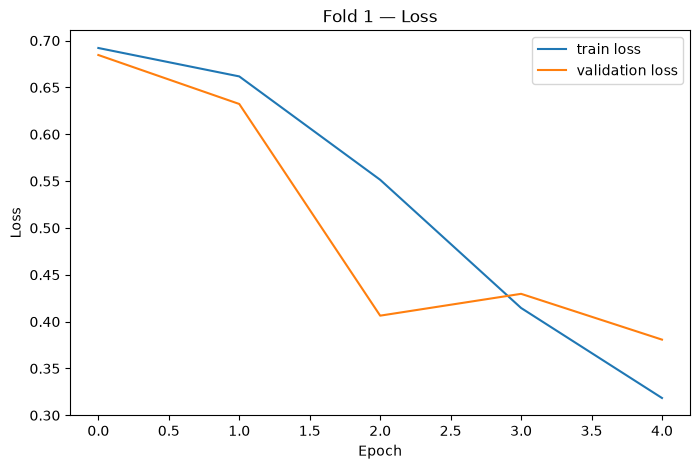

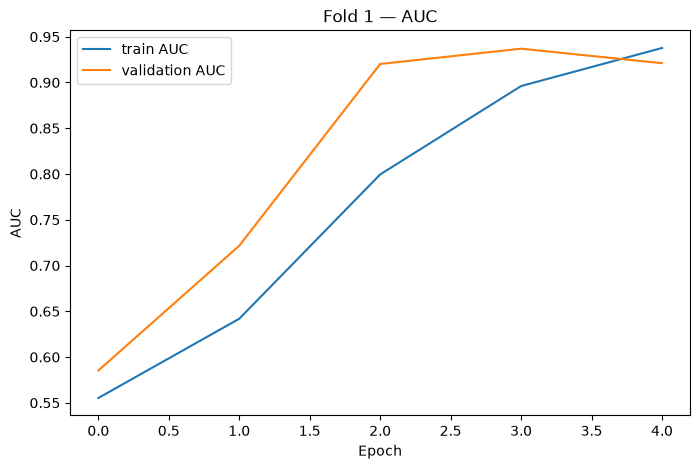

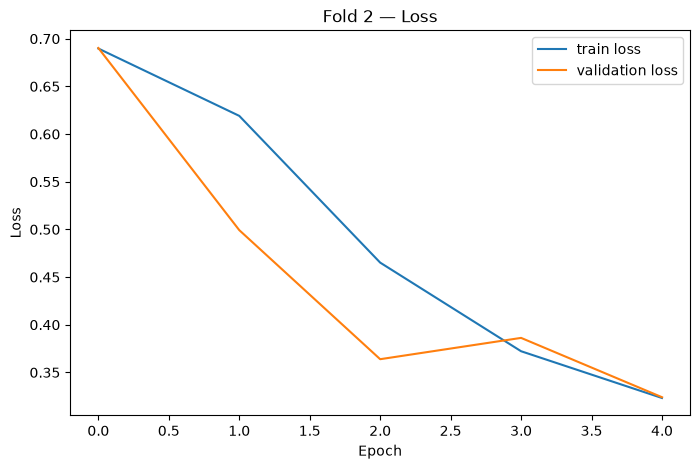

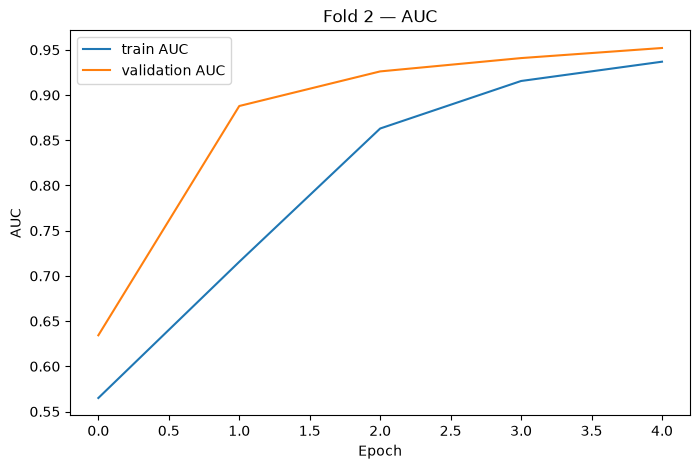

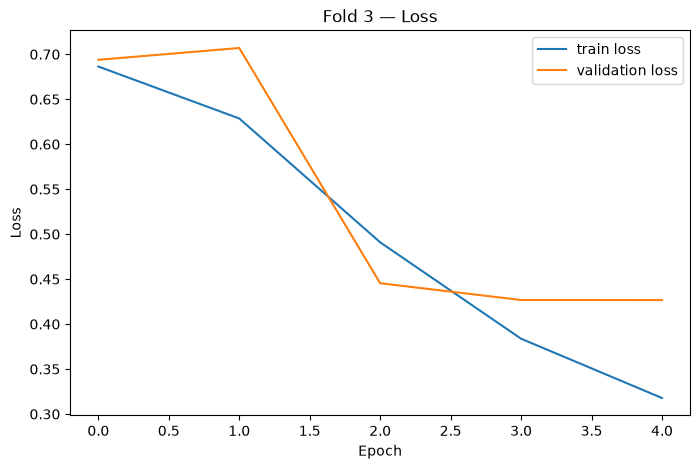

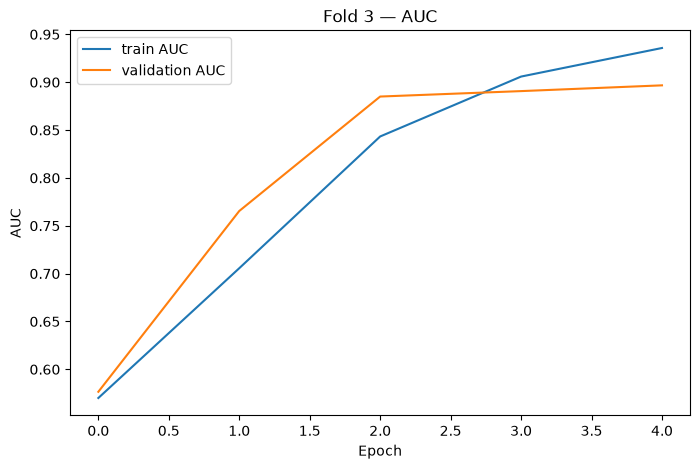

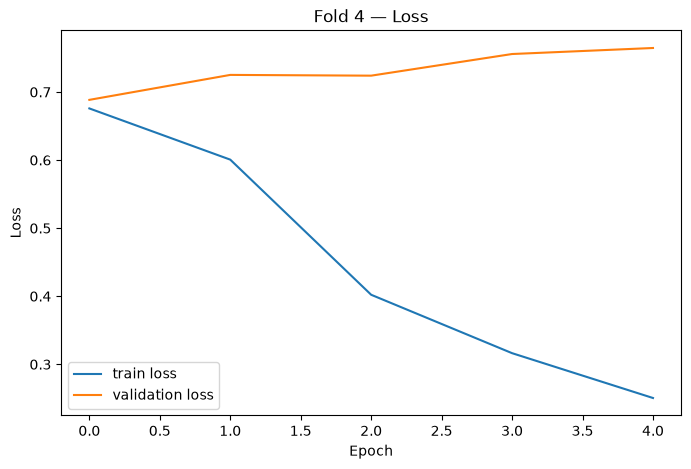

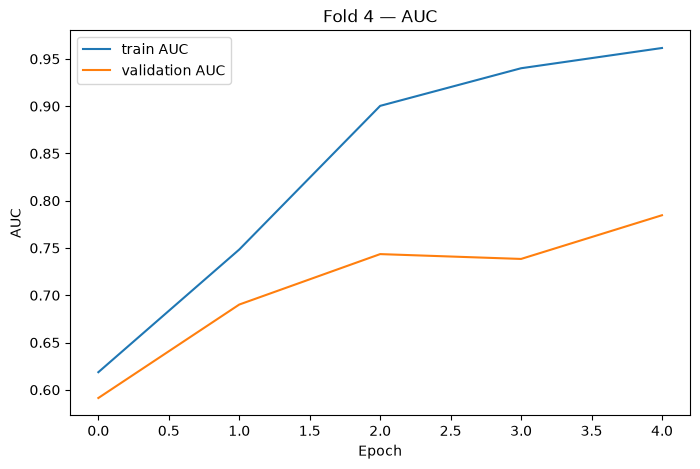

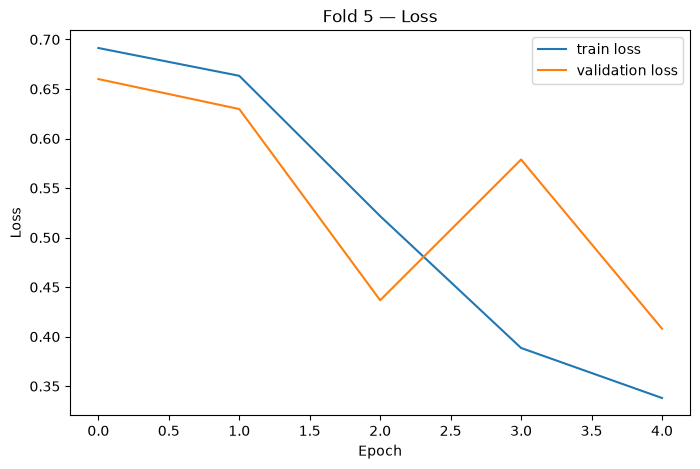

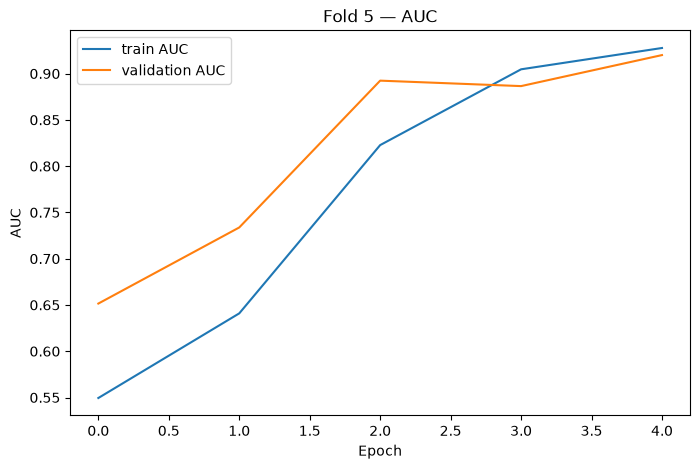

In [90]:
def plot_fold_history(history, fold):
    hist = history.history

    plt.figure(figsize=(8, 5))
    plt.plot(hist['loss'], label='train loss')
    plt.plot(hist['val_loss'], label='validation loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Fold {fold} — Loss')
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(hist['auc'], label='train AUC')
    plt.plot(hist['val_auc'], label='validation AUC')
    plt.xlabel('Epoch')
    plt.ylabel('AUC')
    plt.title(f'Fold {fold} — AUC')
    plt.legend()
    plt.show()


for i, history in enumerate(fold_histories, start=1):
    plot_fold_history(history, i)
